# Full-Covariance Replica Plots

Replica-analysis notebook for the active `Cards/<fit_name>.jl` setup.
It reads `../Fits/replica_data/*.csv`, reevaluates replica predictions on the nominal dataset,
uses the full `Chi2_Matrix/Total_inverse.csv` objective, and reconstructs the Gaussian PDF shifts
used by `fit_replicas_cov_full.ipynb` from `PDF_rep.csv` and the stored `pdf_shift_seed`.


In [1]:
from julia.api import Julia
from julia import Main

import csv
import os
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, LogLocator, MultipleLocator, NullFormatter
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

plt.rcParams["figure.dpi"] = 120


c:\Users\congyue zhang\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fit_name = "Final"
replica_results_path = Path("../Fits/replica_data/replica_0410.csv")

data_selections = "by_experiment"  # "by_file" or "by_experiment"
experiments = [
    "ATLAS_7",
    "ATLAS_8",
    "CDF_I",
    "CDF_II",
    "CMS_7",
    "CMS_8",
    "CMS_13",
    "D0_I",
    "D0_II",
    "D0_II_mu",
    "E288",
    "E605",
    "E772",
    "LHCb_7",
    "LHCb_8",
    "LHCb_13",
    "STAR",
]
file_excludes = [
    "E772/E772-5Q6.csv",
    "E772/E772-6Q7.csv",
    "E772/E772-7Q8.csv",
    "E772/E772-8Q9.csv",
]

approximate_total_xsec = True
use_pdf_shift = True
use_success_only = True
max_replicas = None
band_alpha = 15.865


In [3]:
TMD_fitting_root = Path("../")

def include(name):
    path = (TMD_fitting_root / name).resolve()
    Main.eval(f'include(raw"{path.as_posix()}")')

include(f"Cards/{fit_name}.jl")
include(f"DY/DY_table_{Main.flavor_scheme}.jl")

file_root = Path(f"../Data/{Main.data_name}/Cutted/DY")
matrix_root = Path(f"../Data/{Main.data_name}/Covariance_Matrices/DY")
table_root = Path(f"../Tables/{Main.table_name}/DY")
total_root = Path(f"../Data/DY_total_xsec/{Main.pdf_name}.csv")
chi2_root = Path("../Data/Chi2_Matrix")

initial_params = np.asarray(Main.initial_params, dtype=float)

card_path = TMD_fitting_root / "Cards" / f"{fit_name}.jl"
card_text = card_path.read_text(encoding="utf-8")

struct_match = re.search(r"struct\s+Params_Struct(.*?)end", card_text, re.S)
if struct_match is None:
    raise ValueError(f"Could not find Params_Struct in {card_path}")

param_names = re.findall(
    r"([A-Za-z_][A-Za-z0-9_]*)\s*::\s*Float32",
    struct_match.group(1),
)
param_columns = [f"param_{i}" for i in range(len(param_names))]

frozen_match = re.search(r"frozen_indices\s*=\s*\[([^\]]*)\]", card_text)
frozen_idx = (
    np.asarray([int(x) for x in re.findall(r"-?\d+", frozen_match.group(1))], dtype=int)
    if frozen_match
    else np.asarray([], dtype=int)
)
frozen_set = set(frozen_idx.tolist())

param_info_df = pd.DataFrame(
    {
        "index": np.arange(len(param_names), dtype=int),
        "parameter": param_names,
        "initial_value": initial_params,
        "frozen": [i in frozen_set for i in range(len(param_names))],
    }
)
display(param_info_df)


,index,parameter,initial_value,frozen
0,0,lambda1,0.00315,False
1,1,lambda2,0.98600,False
2,2,lambda3,-2.04000,False
3,3,logx0,-4.30000,False
4,4,sigx,1.23000,False
5,5,amp,-0.27400,False
6,6,BNP,1.49000,False
7,7,c0,0.06650,False
8,8,c1,0.03010,False


In [4]:
def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    if len(num_cols):
        df[num_cols] = df[num_cols].astype("float64")
    return df

if data_selections == "by_file":
    file_names = []
else:
    file_names = []
    for experiment in experiments:
        exp_dir = file_root / experiment
        for path in sorted(exp_dir.glob("*.csv")):
            rel = f"{experiment}/{path.name}"
            if rel in file_excludes:
                continue
            file_names.append(rel)

print(f"Loaded {len(file_names)} datasets")
display(pd.Series(file_names, name="file"))

data_list = {}
matrix_data_list = {}

df_total_xsec = to_float64(pd.read_csv(total_root))
total_xsec_lookup = dict(zip(df_total_xsec["name"], df_total_xsec["total_xsec"]))

for file in tqdm(file_names, desc="Reading data"):
    data_list[file] = to_float64(pd.read_csv(file_root / file))
    matrix_data_list[file] = to_float64(pd.read_csv(matrix_root / file))

    short_name = Path(file).stem
    if short_name in total_xsec_lookup:
        data_list[file]["total_xsec"] = float(total_xsec_lookup[short_name])

normalize_file = lambda p: os.path.normpath(str(p)).replace("\\", "/")
chi2_index_df = pd.read_csv(chi2_root / "Index.csv")
chi2_index_df["file"] = chi2_index_df["file"].astype(str).map(normalize_file)
required_cols = {"global_index", "file", "local_index"}
missing_cols = required_cols - set(chi2_index_df.columns)
if missing_cols:
    raise ValueError(f"Index.csv is missing required columns: {sorted(missing_cols)}")

chi2_index_df = chi2_index_df.sort_values("global_index").reset_index(drop=True)
expected_global = np.arange(len(chi2_index_df), dtype=int)
actual_global = chi2_index_df["global_index"].to_numpy(dtype=int)
if not np.array_equal(actual_global, expected_global):
    raise ValueError("Index.csv global_index must be contiguous and start at 0.")

file_set = {normalize_file(file) for file in file_names}
index_file_set = set(chi2_index_df["file"].unique())
missing_from_index = sorted(file_set - index_file_set)
extra_in_index = sorted(index_file_set - file_set)
if missing_from_index:
    raise ValueError(f"Index.csv is missing active fit files: {missing_from_index}")
if extra_in_index:
    raise ValueError(f"Index.csv contains files not used by this fit: {extra_in_index}")

chi2_file_positions = {}
chi2_file_local_indices = {}
for file, group in chi2_index_df.groupby("file", sort=False):
    chi2_file_positions[file] = group["global_index"].to_numpy(dtype=int)
    chi2_file_local_indices[file] = group["local_index"].to_numpy(dtype=int)

normalized_data_lists = {normalize_file(file): data_list[file] for file in file_names}
for file, local_indices in chi2_file_local_indices.items():
    file_len = len(normalized_data_lists[file])
    if np.any(local_indices < 0) or np.any(local_indices >= file_len):
        raise IndexError(f"Index.csv local_index out of bounds for {file}")

Total_inverse = to_float64(pd.read_csv(chi2_root / "Total_inverse.csv")).to_numpy(dtype=float)
if Total_inverse.shape != (len(chi2_index_df), len(chi2_index_df)):
    raise ValueError(
        f"Total_inverse.csv shape {Total_inverse.shape} does not match Index.csv length {len(chi2_index_df)}"
    )
Total_inverse = 0.5 * (Total_inverse + Total_inverse.T)


Loaded 57 datasets


0       ATLAS_7/ATLAS7-00y10.csv
1       ATLAS_7/ATLAS7-10y20.csv
2       ATLAS_7/ATLAS7-20y24.csv
3       ATLAS_8/ATLAS8-00y04.csv
4       ATLAS_8/ATLAS8-04y08.csv
5       ATLAS_8/ATLAS8-08y12.csv
6     ATLAS_8/ATLAS8-116Q150.csv
7       ATLAS_8/ATLAS8-12y16.csv
8       ATLAS_8/ATLAS8-16y20.csv
9       ATLAS_8/ATLAS8-20y24.csv
10      ATLAS_8/ATLAS8-46Q66.csv
11                CDF_I/CDF1.csv
12               CDF_II/CDF2.csv
13                CMS_7/CMS7.csv
14                CMS_8/CMS8.csv
15        CMS_13/CMS13-00y04.csv
16        CMS_13/CMS13-04y08.csv
17        CMS_13/CMS13-08y12.csv
18      CMS_13/CMS13-106Q170.csv
19        CMS_13/CMS13-12y16.csv
20        CMS_13/CMS13-16y24.csv
21      CMS_13/CMS13-170Q350.csv
22     CMS_13/CMS13-350Q1000.csv
23                  D0_I/D01.csv
24                 D0_II/D02.csv
25            D0_II_mu/D02mu.csv
26         E288/E228-200-4Q5.csv
27         E288/E228-200-5Q6.csv
28         E288/E228-200-6Q7.csv
29         E288/E228-200-7Q8.csv
30        

Reading data: 100%|██████████| 57/57 [00:00<00:00, 372.54it/s]


In [5]:
file_lengths = {file: len(data_list[file]) for file in file_names}

def _norm(path):
    return os.path.normpath(str(path)).replace("\\", "/")


def prediction_reformat(predictions):
    preds = {_norm(k): v for k, v in predictions.items()}
    df_predictions = {}

    for file in file_names:
        n_points = file_lengths[file]
        base = os.path.splitext(file)[0]
        xs = []

        for i in range(n_points):
            candidates = [
                _norm(table_root / f"{base}/{i}.jls"),
                _norm(table_root / f"{base}/{i}.jld2"),
            ]
            for candidate in candidates:
                if candidate in preds:
                    xs.append(preds[candidate])
                    break
            else:
                raise KeyError(f"Missing prediction entry for {file} point {i}")

        xs = np.asarray(xs, dtype=float)
        if approximate_total_xsec and Path(file).stem in total_xsec_lookup:
            data_xsec = data_list[file]["xsec"].to_numpy(dtype=float)
            qT_bin_size = (
                data_list[file]["qT_max"].to_numpy(dtype=float)
                - data_list[file]["qT_min"].to_numpy(dtype=float)
            )
            weighted_data = np.sum(data_xsec * qT_bin_size)
            weighted_theory = np.sum(xs * qT_bin_size)
            if weighted_theory != 0.0:
                xs = xs * (weighted_data / weighted_theory)

        df_predictions[file] = xs

    return df_predictions


zero_pdf_shift_vector = np.zeros((len(chi2_index_df), 1), dtype=np.float64)

if use_pdf_shift:
    pdf_rep_path = chi2_root / "PDF_rep.csv"
    PDF_rep = to_float64(pd.read_csv(pdf_rep_path)).to_numpy(dtype=float)
    if PDF_rep.ndim == 1:
        PDF_rep = PDF_rep.reshape(-1, 1)
    if PDF_rep.shape[0] != len(chi2_index_df):
        raise ValueError(
            f"PDF_rep.csv shape {PDF_rep.shape} is incompatible with Index.csv length {len(chi2_index_df)}"
        )
    print(f"Loaded Gaussian PDF shift basis {PDF_rep.shape} from {pdf_rep_path}")
else:
    PDF_rep = np.zeros((len(chi2_index_df), 0), dtype=float)
    print("Gaussian PDF shifts are disabled.")


def _coerce_index_df(index_source):
    if isinstance(index_source, pd.DataFrame):
        index_df = index_source.copy()
    else:
        index_df = pd.DataFrame(index_source)

    required_cols = ["global_index", "file", "local_index"]
    missing_cols = [col for col in required_cols if col not in index_df.columns]
    if missing_cols:
        raise ValueError(f"Index source is missing required columns: {missing_cols}")

    index_df["file"] = index_df["file"].astype(str).map(_norm)
    index_df = index_df.sort_values("global_index").reset_index(drop=True)
    return index_df


def build_indexed_column_vector(index_source, arrays_by_file):
    index_df = _coerce_index_df(index_source)
    normalized_arrays = {_norm(file): values for file, values in arrays_by_file.items()}
    vector = np.full((len(index_df), 1), np.nan, dtype=float)

    for file, group in index_df.groupby("file", sort=False):
        if file not in normalized_arrays:
            raise KeyError(f"Missing values for {file} in arrays_by_file")

        values = np.asarray(normalized_arrays[file], dtype=float).reshape(-1)
        local_indices = group["local_index"].to_numpy(dtype=int)
        if np.any(local_indices < 0) or np.any(local_indices >= len(values)):
            raise IndexError(f"Indexed local positions are out of bounds for {file}")

        global_indices = group["global_index"].to_numpy(dtype=int)
        vector[global_indices, 0] = values[local_indices]

    if np.isnan(vector).any():
        raise ValueError("Indexed column vector has unfilled entries. Check Index.csv coverage.")

    return vector


def indexed_vector_to_arrays(index_source, vector, lengths_by_file):
    index_df = _coerce_index_df(index_source)
    values = np.asarray(vector, dtype=float).reshape(len(index_df))
    arrays_by_file = {}

    for file, group in index_df.groupby("file", sort=False):
        local_indices = group["local_index"].to_numpy(dtype=int)
        global_indices = group["global_index"].to_numpy(dtype=int)
        file_values = np.full(lengths_by_file[file], np.nan, dtype=float)
        file_values[local_indices] = values[global_indices]
        if np.isnan(file_values).any():
            raise ValueError(f"Shifted prediction vector does not cover every point in {file}")
        arrays_by_file[file] = file_values

    return arrays_by_file


def get_prediction_column_vector(index_source, df_predictions):
    return build_indexed_column_vector(index_source, df_predictions)


def get_data_column_vector(index_source, source_data_list=None):
    if source_data_list is None:
        source_data_list = data_list
    arrays_by_file = {
        file: source_data_list[file]["xsec"].to_numpy(dtype=float)
        for file in source_data_list
    }
    return build_indexed_column_vector(index_source, arrays_by_file)


def apply_pdf_shift_to_prediction_vector(prediction_vector, pdf_shift_vector):
    prediction_vector = np.asarray(prediction_vector, dtype=float).reshape(len(chi2_index_df), 1)
    pdf_shift_vector = np.asarray(pdf_shift_vector, dtype=float).reshape(len(chi2_index_df), 1)
    return prediction_vector + pdf_shift_vector


def apply_pdf_shift(df_predictions, pdf_shift_vector):
    prediction_vector = get_prediction_column_vector(chi2_index_df, df_predictions)
    shifted_vector = apply_pdf_shift_to_prediction_vector(prediction_vector, pdf_shift_vector)
    return indexed_vector_to_arrays(chi2_index_df, shifted_vector, file_lengths)


def gaussian_pdf_shift_from_seed(pdf_shift_seed):
    if (not use_pdf_shift) or PDF_rep.shape[1] == 0 or pd.isna(pdf_shift_seed):
        return zero_pdf_shift_vector.copy()

    pdf_rng = np.random.default_rng(int(pdf_shift_seed))
    z = pdf_rng.standard_normal(PDF_rep.shape[1])
    return (PDF_rep @ z).reshape(len(chi2_index_df), 1)


def set_params_and_predict(full_params, pdf_shift_vector=None):
    params_cl = Main.Params_Struct(*[np.float32(x) for x in full_params])
    Main.set_params(Main.VRAM, params_cl)
    predictions, eval_time = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    df_predictions = prediction_reformat(predictions)
    if pdf_shift_vector is not None:
        df_predictions = apply_pdf_shift(df_predictions, pdf_shift_vector)
    return df_predictions, float(eval_time)


Loaded Gaussian PDF shift basis (465, 99) from ..\Data\Chi2_Matrix\PDF_rep.csv


In [6]:
def get_chi2dN_from_prediction_vector(prediction_vector, source_data_list=None):
    if source_data_list is None:
        source_data_list = data_list

    prediction_vector = np.asarray(prediction_vector, dtype=float).reshape(len(chi2_index_df), 1)
    current_data_vector = get_data_column_vector(chi2_index_df, source_data_list)
    diff_vector = current_data_vector - prediction_vector
    weighted_diff = Total_inverse @ diff_vector

    chi2_total = float((diff_vector.T @ weighted_diff)[0, 0])
    n_total = int(diff_vector.shape[0])
    point_contributions = diff_vector[:, 0] * weighted_diff[:, 0]

    chi2_by_file = {}
    n_by_file = {}
    for file in chi2_index_df["file"].unique():
        positions = chi2_file_positions[file]
        n_points = len(positions)
        chi2_file = float(np.sum(point_contributions[positions]))
        chi2_by_file[file] = chi2_file / n_points
        n_by_file[file] = n_points

    return chi2_total / n_total, chi2_by_file, n_by_file


def get_chi2dN(df_predictions, pdf_shift_vector=None, source_data_list=None):
    prediction_vector = get_prediction_column_vector(chi2_index_df, df_predictions)
    if pdf_shift_vector is not None:
        prediction_vector = apply_pdf_shift_to_prediction_vector(prediction_vector, pdf_shift_vector)
    return get_chi2dN_from_prediction_vector(prediction_vector, source_data_list)


central_predictions, central_eval_time = set_params_and_predict(
    initial_params,
    zero_pdf_shift_vector if use_pdf_shift else None,
)
central_chi2dN, chi2_by_file, n_by_file = get_chi2dN(central_predictions)

print(f"Central prediction chi2/N = {central_chi2dN:.4f}")
print(f"One central evaluation took {central_eval_time * 1000.0:.1f} ms")

per_file_df = pd.DataFrame(
    {
        "chi2dN": pd.Series(chi2_by_file),
        "n_points": pd.Series(n_by_file),
    }
).sort_index()
display(per_file_df)


Central prediction chi2/N = 1.1198
One central evaluation took 315.4 ms


,chi2dN,n_points
ATLAS_7/ATLAS7-00y10.csv,4.378105,6
ATLAS_7/ATLAS7-10y20.csv,5.794702,6
ATLAS_7/ATLAS7-20y24.csv,1.304101,6
ATLAS_8/ATLAS8-00y04.csv,3.789838,6
ATLAS_8/ATLAS8-04y08.csv,0.226394,6
ATLAS_8/ATLAS8-08y12.csv,1.221473,6
ATLAS_8/ATLAS8-116Q150.csv,0.674094,8
ATLAS_8/ATLAS8-12y16.csv,3.168687,6
ATLAS_8/ATLAS8-16y20.csv,0.840392,6
ATLAS_8/ATLAS8-20y24.csv,1.441546,6


In [7]:
def load_replica_results(path):
    required_columns = [
        "replica_id",
        "success",
        "nfev",
        "best_chi2dN",
        *param_columns,
    ]

    df = pd.read_csv(path)
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")

    if "pdf_replica_id" not in df.columns:
        df["pdf_replica_id"] = pd.Series(pd.array([pd.NA] * len(df), dtype="string"), index=df.index)
    else:
        df["pdf_replica_id"] = df["pdf_replica_id"].astype("string")

    if "pdf_shift_seed" not in df.columns:
        df["pdf_shift_seed"] = pd.Series(pd.array([pd.NA] * len(df), dtype="Int64"), index=df.index)
    else:
        df["pdf_shift_seed"] = pd.to_numeric(df["pdf_shift_seed"], errors="coerce").astype("Int64")

    numeric_columns = ["replica_id", "success", "nfev", "best_chi2dN", *param_columns]
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=required_columns).copy()
    df["replica_id"] = df["replica_id"].astype(int)
    df["success"] = df["success"].astype("Int64")
    df["nfev"] = df["nfev"].astype("Int64")

    bad_success_values = sorted(set(df["success"].dropna().astype(int)) - {0, 1})
    if bad_success_values:
        raise ValueError(
            f"Parsed success column contains non-binary values {bad_success_values}; CSV schema may be misaligned"
        )

    if use_pdf_shift:
        pdf_mode = df["pdf_replica_id"].fillna("").str.strip().str.lower()
        unsupported_mask = (~pdf_mode.isin(["", "off", "gaussian"]))
        if unsupported_mask.any():
            bad_values = sorted(set(df.loc[unsupported_mask, "pdf_replica_id"].dropna().astype(str)))
            raise ValueError(
                "plot_cov_full expects Gaussian PDF shifts from fit_replicas_cov_full; "
                f"unsupported pdf_replica_id values found: {bad_values}"
            )

        missing_seed_mask = pdf_mode.eq("gaussian") & df["pdf_shift_seed"].isna()
        if missing_seed_mask.any():
            bad_ids = df.loc[missing_seed_mask, "replica_id"].astype(int).tolist()
            raise ValueError(
                "Gaussian PDF-shift rows are missing pdf_shift_seed values for replica_id "
                f"{bad_ids[:10]}"
            )

    for col, name in zip(param_columns, param_names):
        df[name] = df[col]

    return df.sort_values("replica_id").reset_index(drop=True)


replica_results_all_df = load_replica_results(replica_results_path)
replica_results_df = replica_results_all_df.copy()
if use_success_only:
    replica_results_df = replica_results_df[replica_results_df["success"] == 1].reset_index(drop=True)
if max_replicas is not None:
    replica_results_df = replica_results_df.head(max_replicas).copy()

print(f"Loaded {len(replica_results_df)} replica refits from {replica_results_path}")
print(f"use_success_only = {use_success_only}")
print("success counts in source file:")
display(replica_results_all_df["success"].value_counts(dropna=False).sort_index().rename("count").to_frame())

duplicate_counts = replica_results_all_df["replica_id"].value_counts()
duplicate_ids = duplicate_counts[duplicate_counts > 1]
if not duplicate_ids.empty:
    print("warning: duplicate replica_id values found in source file")
    display(duplicate_ids.rename("count").to_frame())

preview_cols = ["replica_id", "pdf_replica_id", "pdf_shift_seed", "success", "best_chi2dN", *param_names[: min(4, len(param_names))]]
display(replica_results_df[preview_cols].head())
display(replica_results_df[["best_chi2dN", "nfev"]].describe())


Loaded 72 replica refits from ..\Fits\replica_data\replica_0410.csv
use_success_only = True
success counts in source file:


,count
success,
0,28
1,72


,replica_id,pdf_replica_id,pdf_shift_seed,success,best_chi2dN,lambda1,lambda2,lambda3,logx0
0,0,gaussian,5830217695817921349,1,2.146382,-0.000702,0.989687,-1.913334,-3.847237
1,1,gaussian,224308479026628678,1,1.958509,-0.001271,1.028435,-2.160632,-4.609835
2,2,gaussian,2783458671071757400,1,2.051226,-0.013528,1.038007,-2.197349,-4.362353
3,5,gaussian,4953569482622441360,1,2.064765,-0.000387,0.989919,-1.927616,-4.945806
4,6,gaussian,6045377789372138287,1,1.997993,-0.008225,0.979822,-2.112394,-5.042582


,best_chi2dN,nfev
count,72.000000,72.0
mean,2.107229,1353.861111
std,0.117717,280.226835
min,1.756990,800.0
25%,2.026276,993.75
50%,2.107511,1513.0
75%,2.197608,1564.0
max,2.344126,1604.0


In [8]:
prediction_dicts = {file: [] for file in file_names}
replica_eval_rows = []

for row in tqdm(
    replica_results_df.itertuples(index=False),
    total=len(replica_results_df),
    desc="Evaluating replicas",
):
    full_params = np.array([getattr(row, col) for col in param_columns], dtype=float)
    pdf_replica_id = None if pd.isna(row.pdf_replica_id) else str(row.pdf_replica_id)
    pdf_shift_seed = None if pd.isna(row.pdf_shift_seed) else int(row.pdf_shift_seed)
    pdf_shift_vector = gaussian_pdf_shift_from_seed(pdf_shift_seed) if use_pdf_shift else None

    df_predictions, eval_time = set_params_and_predict(full_params, pdf_shift_vector)
    eval_chi2dN, _, _ = get_chi2dN(df_predictions)

    replica_eval_rows.append(
        {
            "replica_id": int(row.replica_id),
            "pdf_replica_id": pdf_replica_id,
            "pdf_shift_seed": pdf_shift_seed,
            "fit_chi2dN": float(row.best_chi2dN),
            "nominal_eval_chi2dN": float(eval_chi2dN),
            "eval_time_ms": 1000.0 * float(eval_time),
        }
    )

    for file in file_names:
        prediction_dicts[file].append(np.asarray(df_predictions[file], dtype=float))

replica_eval_df = pd.DataFrame(replica_eval_rows)
display(replica_eval_df.head())
print(
    "fit_chi2dN is the saved replica-fit objective on replica data; nominal_eval_chi2dN is the reevaluation "
    "on the nominal dataset with the stored Gaussian PDF shift, so they are not expected to match."
)
display(replica_eval_df[["fit_chi2dN", "nominal_eval_chi2dN", "eval_time_ms"]].describe())


Evaluating replicas: 100%|██████████| 72/72 [00:05<00:00, 12.29it/s]


,replica_id,pdf_replica_id,pdf_shift_seed,fit_chi2dN,nominal_eval_chi2dN,eval_time_ms
0,0,gaussian,5830217695817921349,2.146382,1.164640,37.2208
1,1,gaussian,224308479026628678,1.958509,1.132663,37.0868
2,2,gaussian,2783458671071757400,2.051226,1.133639,36.9772
3,5,gaussian,4953569482622441360,2.064765,1.148848,37.1688
4,6,gaussian,6045377789372138287,1.997993,1.144551,37.0452


fit_chi2dN is the saved replica-fit objective on replica data; nominal_eval_chi2dN is the reevaluation on the nominal dataset with the stored Gaussian PDF shift, so they are not expected to match.


,fit_chi2dN,nominal_eval_chi2dN,eval_time_ms
count,72.000000,72.000000,72.000000
mean,2.107229,1.147582,37.322085
std,0.117717,0.026011,0.284022
min,1.756990,1.094814,36.977200
25%,2.026276,1.129396,37.113600
50%,2.107511,1.147551,37.226800
75%,2.197608,1.166247,37.466550
max,2.344126,1.230828,38.522300


In [9]:
quantiles = [band_alpha / 100.0, 0.5, 1.0 - band_alpha / 100.0]
plots_list = {}

for file in file_names:
    preds_array = np.asarray(prediction_dicts[file], dtype=float)
    pred_lo, pred_mid, pred_hi = np.quantile(preds_array, quantiles, axis=0)

    data_df = data_list[file]
    data_vals = data_df["xsec"].to_numpy(dtype=float)
    qT_vals = data_df["qT_mean"].to_numpy(dtype=float)
    central_vals = np.asarray(central_predictions[file], dtype=float)

    data_cov = np.asarray(matrix_data_list[file], dtype=float)
    data_err = np.sqrt(np.clip(np.diag(data_cov), 0.0, None))

    ratio_lo = np.divide(pred_lo, data_vals, out=np.full(pred_lo.shape, np.nan), where=data_vals != 0.0)
    ratio_mid = np.divide(pred_mid, data_vals, out=np.full(pred_mid.shape, np.nan), where=data_vals != 0.0)
    ratio_hi = np.divide(pred_hi, data_vals, out=np.full(pred_hi.shape, np.nan), where=data_vals != 0.0)
    central_ratio = np.divide(
        central_vals,
        data_vals,
        out=np.full(central_vals.shape, np.nan),
        where=data_vals != 0.0,
    )
    ratio_err = np.divide(
        data_err,
        np.abs(data_vals),
        out=np.full(data_err.shape, np.nan),
        where=data_vals != 0.0,
    )

    plots_list[file] = pd.DataFrame(
        {
            "qT": qT_vals,
            "data": data_vals,
            "data_err": data_err,
            "central": central_vals,
            "pred_lo": pred_lo,
            "pred_mid": pred_mid,
            "pred_hi": pred_hi,
            "ratio_lo": ratio_lo,
            "ratio_mid": ratio_mid,
            "ratio_hi": ratio_hi,
            "central_ratio": central_ratio,
            "ratio_err": ratio_err,
        }
    )

print(f"Prepared plot inputs for {len(plots_list)} datasets")


Prepared plot inputs for 57 datasets


In [10]:
e288_files = [file for file in file_names if file.startswith("E288/") and file in plots_list]


def parse_e288_key(file):
    stem = Path(file).stem
    match = re.match(r"E228-(\d+)-(\d+(?:\.\d+)?)Q(\d+(?:\.\d+)?)$", stem)
    if match is None:
        raise ValueError(f"Unexpected E288 file name: {stem}")
    beam = int(match.group(1))
    q_lo = float(match.group(2))
    q_hi = float(match.group(3))
    return beam, q_lo, q_hi


def parse_mass_bin_key(file, experiment):
    stem = Path(file).stem
    match = re.match(
        rf"{re.escape(experiment)}-(\d+(?:\.\d+)?)Q(\d+(?:\.\d+)?)$",
        stem,
    )
    if match is None:
        raise ValueError(f"Unexpected {experiment} file name: {stem}")
    q_lo = float(match.group(1))
    q_hi = float(match.group(2))
    return q_lo, q_hi


def step_xy(x_min, x_max, values):
    edges = np.concatenate(([float(x_min[0])], np.asarray(x_max, dtype=float)))
    x_curve = np.repeat(edges, 2)[1:-1]
    y_curve = np.repeat(np.asarray(values, dtype=float), 2)
    return x_curve, y_curve


def choose_round_step(x_max, target_ticks=5):
    candidates = (0.25, 0.5, 1.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


def make_q_bin_colors(q_bin_order):
    return {q_bin: f"C{idx % 10}" for idx, q_bin in enumerate(q_bin_order)}


def plot_q_bin_overlay(ax, dataset_specs, q_bin_colors, scale_factors=None):
    if scale_factors is None:
        scale_factors = {}
    for q_lo, q_hi, fname in dataset_specs:
        q_key = (q_lo, q_hi)
        d = plots_list[fname]
        raw_df = data_list[fname]

        qT = d["qT"].to_numpy(dtype=float)
        qT_min = raw_df["qT_min"].to_numpy(dtype=float)
        qT_max = raw_df["qT_max"].to_numpy(dtype=float)
        data_vals = d["data"].to_numpy(dtype=float)
        data_err = d["data_err"].to_numpy(dtype=float)
        central = d["central"].to_numpy(dtype=float)
        pred_lo = d["pred_lo"].to_numpy(dtype=float)
        pred_hi = d["pred_hi"].to_numpy(dtype=float)

        scale = float(scale_factors.get(q_key, 1.0))
        data_vals = scale * data_vals
        data_err = scale * data_err
        central = scale * central
        pred_lo = scale * pred_lo
        pred_hi = scale * pred_hi

        x_curve, central_curve = step_xy(qT_min, qT_max, central)
        _, lo_curve = step_xy(qT_min, qT_max, pred_lo)
        _, hi_curve = step_xy(qT_min, qT_max, pred_hi)

        color = q_bin_colors[q_key]

        ax.errorbar(
            qT,
            data_vals,
            yerr=data_err,
            fmt="o",
            ms=4.0,
            elinewidth=1.0,
            capsize=2.8,
            color=color,
            mec=color,
            mfc="white",
        )
        ax.fill_between(x_curve, lo_curve, hi_curve, color=color, alpha=0.3, linewidth=0.0)
        ax.plot(x_curve, central_curve, color=color, linewidth=1.2, drawstyle="steps-mid")
        if scale != 1.0:
            ax.annotate(
                f"x {scale:g}",
                xy=(float(qT_max[-1]), float(central[-1])),
                xytext=(8, 0),
                textcoords="offset points",
                color=color,
                fontsize=8,
                ha="left",
                va="center",
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 0.2},
                clip_on=False,
            )


def build_q_bin_legend_handles(q_bin_order, q_bin_colors, scale_factors=None):
    return [
        plt.Line2D(
            [0],
            [0],
            color=q_bin_colors[q_bin],
            linewidth=1.4,
            label=f"{q_bin[0]:g} < Q < {q_bin[1]:g} GeV",
        )
        for q_bin in q_bin_order
    ]


def set_round_xticks(ax, panel_x_max, include_right_edge):
    x_tick_step = choose_round_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)
    if include_right_edge:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    ax.set_xlim(0.0, x_upper)
    ax.set_xticks(x_ticks)
    return x_upper, x_tick_step


def apply_dense_minor_ticks(ax, x_tick_step, y_scale):
    ax.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    if y_scale == "log":
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
    else:
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)


def plot_ratio_panel(ax, fname, color="C0"):
    d = plots_list[fname]
    raw_df = data_list[fname]

    qT = d["qT"].to_numpy(dtype=float)
    qT_min = raw_df["qT_min"].to_numpy(dtype=float)
    qT_max = raw_df["qT_max"].to_numpy(dtype=float)
    ratio_err = d["ratio_err"].to_numpy(dtype=float)
    central_ratio = d["central_ratio"].to_numpy(dtype=float)
    ratio_lo = d["ratio_lo"].to_numpy(dtype=float)
    ratio_hi = d["ratio_hi"].to_numpy(dtype=float)

    x_curve, central_curve = step_xy(qT_min, qT_max, central_ratio)
    _, lo_curve = step_xy(qT_min, qT_max, ratio_lo)
    _, hi_curve = step_xy(qT_min, qT_max, ratio_hi)

    ax.axhline(1.0, color="0.5", linewidth=0.9, linestyle="--")
    ax.errorbar(
        qT,
        np.ones_like(qT),
        yerr=ratio_err,
        fmt="o",
        ms=4.0,
        elinewidth=1.0,
        capsize=2.8,
        color=color,
        mec=color,
        mfc="white",
    )
    ax.fill_between(x_curve, lo_curve, hi_curve, color=color, alpha=0.3, linewidth=0.0)
    ax.plot(x_curve, central_curve, color=color, linewidth=1.2, drawstyle="steps-mid")


PROTON_MASS_GEV = 0.9382720813
HIGH_ENERGY_COLOR = "#7757D9"


def fixed_target_sqrt_s(beam_energy_gev):
    s_value = 2.0 * PROTON_MASS_GEV**2 + 2.0 * PROTON_MASS_GEV * beam_energy_gev
    return np.sqrt(s_value)


e288_by_beam = {}
all_q_bins = set()
for file in e288_files:
    beam, q_lo, q_hi = parse_e288_key(file)
    e288_by_beam.setdefault(beam, []).append((q_lo, q_hi, file))
    all_q_bins.add((q_lo, q_hi))

for beam in e288_by_beam:
    e288_by_beam[beam] = sorted(e288_by_beam[beam], key=lambda item: (item[0], item[1]))

beam_order = [beam for beam in [200, 300, 400] if beam in e288_by_beam]
if not beam_order:
    raise ValueError("No E288 datasets are available in the current selection")

q_bin_order = sorted(all_q_bins)
q_bin_colors = make_q_bin_colors(q_bin_order)

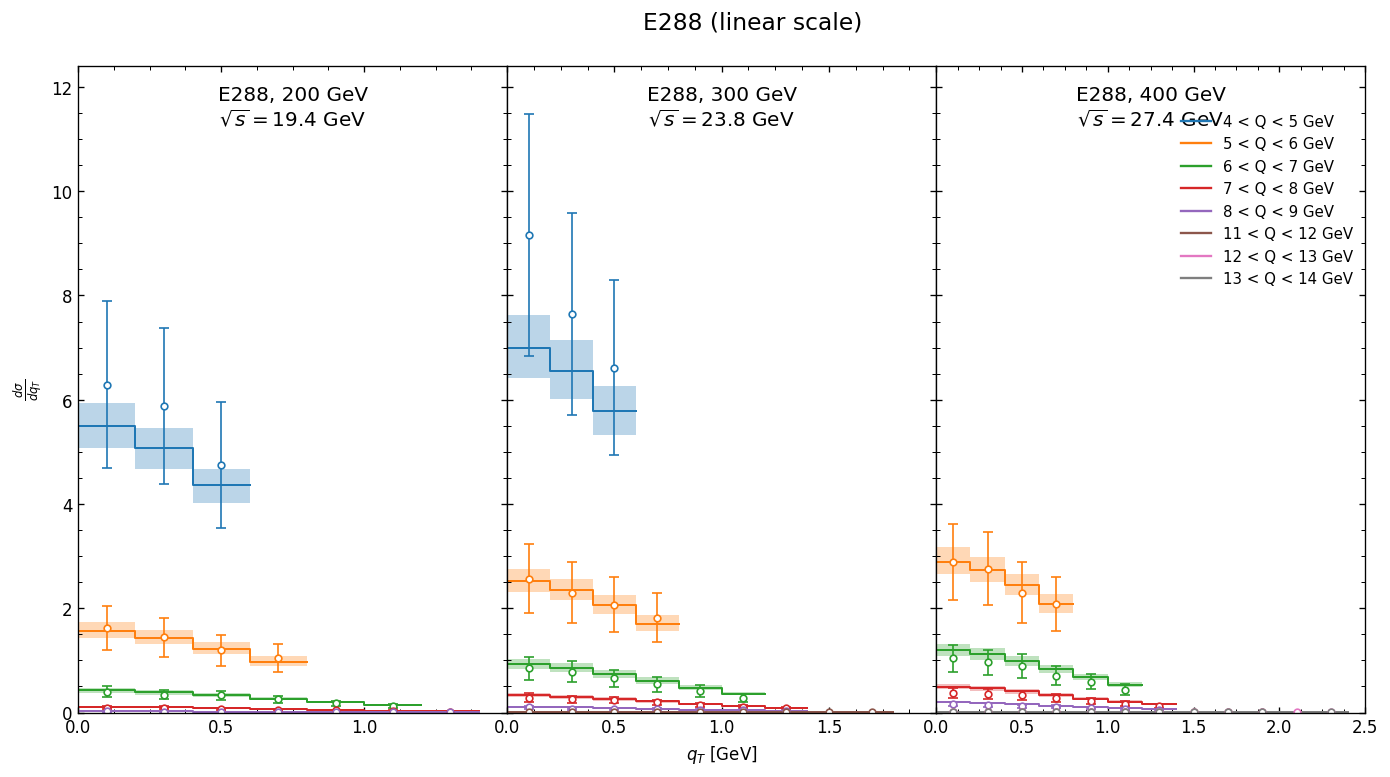

In [11]:
fig, axes = plt.subplots(1, len(beam_order), figsize=(15, 7), sharey=True)
if len(beam_order) == 1:
    axes = [axes]

fig.subplots_adjust(wspace=0.0, right=0.84, top=0.92, bottom=0.15)
fig.suptitle("E288 (linear scale)", fontsize=14, y=0.985)

global_y_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(
            np.nanmax(
                plots_list[fname]["data"].to_numpy(dtype=float)
                + plots_list[fname]["data_err"].to_numpy(dtype=float)
            )
        ),
    )
    for beam in beam_order
    for _, _, fname in e288_by_beam[beam]
)
global_y_max *= 1.08

for panel_idx, (ax, beam) in enumerate(zip(axes, beam_order)):
    panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e288_by_beam[beam])
    plot_q_bin_overlay(ax, e288_by_beam[beam], q_bin_colors)

    sqrt_s_value = fixed_target_sqrt_s(float(beam))
    ax.text(
        0.5,
        0.97,
        f"E288, {beam} GeV\n$\\sqrt{{s}} = {sqrt_s_value:.1f}\ \mathrm{{GeV}}$",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    if panel_idx == len(beam_order) // 2:
        ax.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax.set_xlabel("")
    _, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=panel_idx == len(beam_order) - 1)
    apply_dense_minor_ticks(ax, x_tick_step, y_scale="linear")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(False)
    ax.set_ylim(0.0, global_y_max)

    if panel_idx > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r"$\frac{d\sigma}{dq_T}$")

fig.legend(
    handles=build_q_bin_legend_handles(q_bin_order, q_bin_colors),
    loc="center left",
    bbox_to_anchor=(0.73, 0.76),
    frameon=False,
    fontsize=9,
)

plt.show()

Final Plots

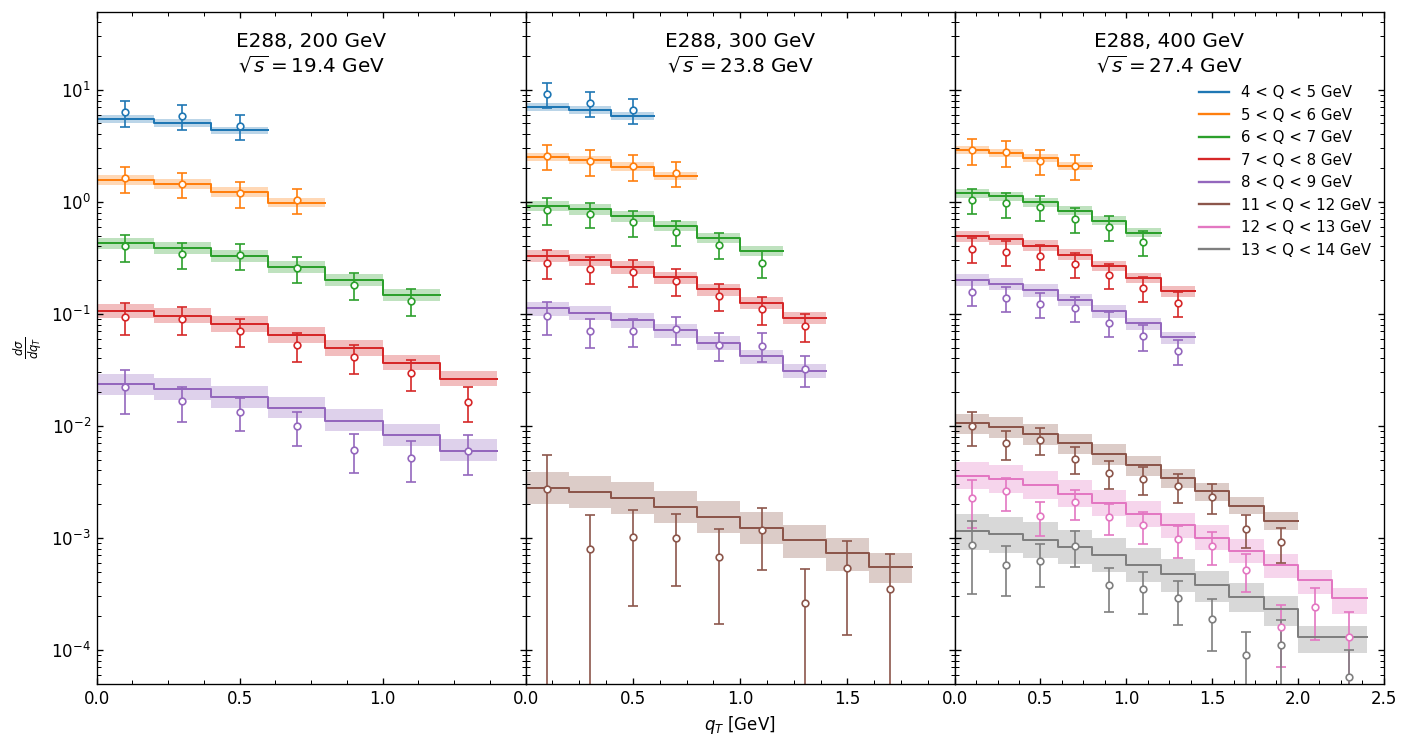

In [12]:


fig, axes = plt.subplots(1, len(beam_order), figsize=(15, 7), sharey=True)
if len(beam_order) == 1:
    axes = [axes]

fig.subplots_adjust(wspace=0.0, right=0.84, top=0.95, bottom=0.15)

for panel_idx, (ax, beam) in enumerate(zip(axes, beam_order)):
    panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e288_by_beam[beam])
    plot_q_bin_overlay(ax, e288_by_beam[beam], q_bin_colors)

    sqrt_s_value = fixed_target_sqrt_s(float(beam))
    ax.text(
        0.5,
        0.97,
        f"E288, {beam} GeV\n$\\sqrt{{s}} = {sqrt_s_value:.1f}\ \mathrm{{GeV}}$",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    if panel_idx == len(beam_order) // 2:
        ax.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax.set_xlabel("")
    ax.set_yscale("log")
    _, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=panel_idx == len(beam_order) - 1)
    apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(False)

    if panel_idx > 0:
        ax.tick_params(labelleft=False)

axes[0].set_ylabel(r"$\frac{d\sigma}{dq_T}$")

fig.legend(
    handles=build_q_bin_legend_handles(q_bin_order, q_bin_colors),
    loc="center left",
    bbox_to_anchor=(0.73, 0.76),
    frameon=False,
    fontsize=9,
)

plt.ylim(5e-5, 50)
plt.show()


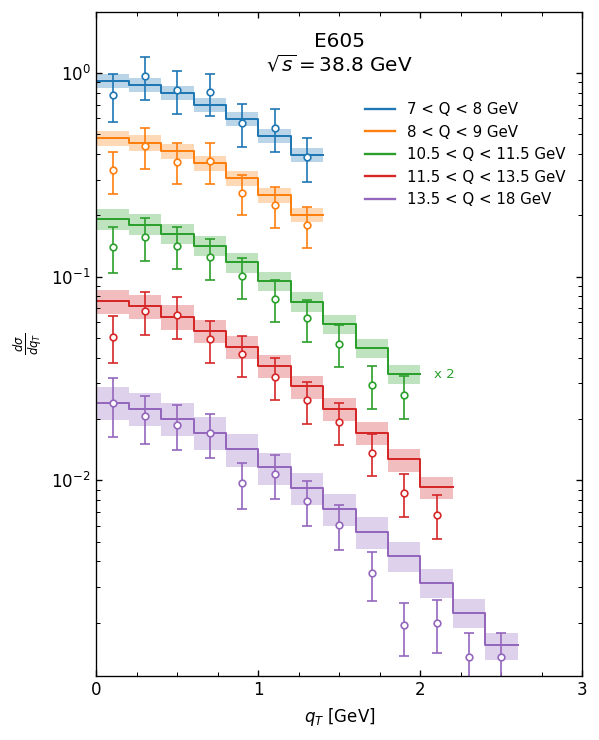

In [13]:
e605_files = [file for file in file_names if file.startswith("E605/") and file in plots_list]

if not e605_files:
    raise ValueError("No E605 datasets are available in the current selection")

e605_specs = []
for file in e605_files:
    q_lo, q_hi = parse_mass_bin_key(file, "E605")
    e605_specs.append((q_lo, q_hi, file))

e605_specs = sorted(e605_specs, key=lambda item: (item[0], item[1]))
e605_q_bins = [(q_lo, q_hi) for q_lo, q_hi, _ in e605_specs]
e605_scale_factors = {
    (10.5, 11.5): 2.0,
}
e605_colors = make_q_bin_colors(e605_q_bins)

fig, ax = plt.subplots(1, 1, figsize=(6, 7))
fig.subplots_adjust(right=0.8, top=0.95, bottom=0.16)

panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e605_specs)
plot_q_bin_overlay(ax, e605_specs, e605_colors, scale_factors=e605_scale_factors)

ax.text(
    0.5,
    0.97,
    f"E605\n$\\sqrt{{s}} = {fixed_target_sqrt_s(800.0):.1f}\ \mathrm{{GeV}}$",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax.set_xlabel(r"$q_T$ [GeV]")
ax.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ax.set_yscale("log")
_, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=True)
apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(False)

fig.legend(
    handles=build_q_bin_legend_handles(e605_q_bins, e605_colors, scale_factors=e605_scale_factors),
    loc="center left",
    bbox_to_anchor=(0.48, 0.78),
    frameon=False,
    fontsize=9,
)

plt.ylim(1.1e-3, 2)
plt.show()


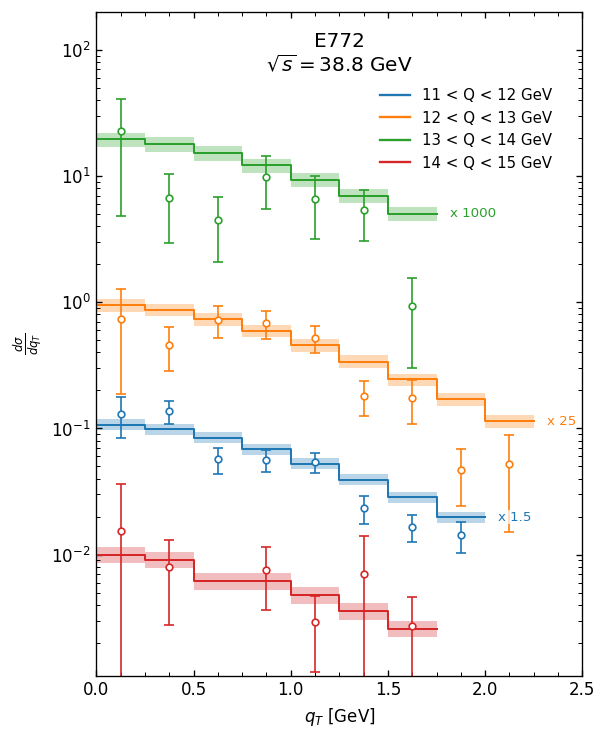

In [14]:
e772_files = [file for file in file_names if file.startswith("E772/") and file in plots_list]

if not e772_files:
    raise ValueError("No E772 datasets are available in the current selection")

e772_specs = []
for file in e772_files:
    q_lo, q_hi = parse_mass_bin_key(file, "E772")
    e772_specs.append((q_lo, q_hi, file))

e772_specs = sorted(e772_specs, key=lambda item: (item[0], item[1]))
e772_q_bins = [(q_lo, q_hi) for q_lo, q_hi, _ in e772_specs]
e772_scale_factors = {
    (11.0, 12.0): 1.5,
    (12.0, 13.0): 25.0,
    (13.0, 14.0): 1000.0,
}
e772_colors = make_q_bin_colors(e772_q_bins)

fig, ax = plt.subplots(1, 1, figsize=(6, 7))
fig.subplots_adjust(right=0.8, top=0.95, bottom=0.16)

panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in e772_specs)
plot_q_bin_overlay(ax, e772_specs, e772_colors, scale_factors=e772_scale_factors)

ax.text(
    0.5,
    0.97,
    f"E772\n$\\sqrt{{s}} = {fixed_target_sqrt_s(800.0):.1f}\ \mathrm{{GeV}}$",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax.set_xlabel(r"$q_T$ [GeV]")
ax.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ax.set_yscale("log")
_, x_tick_step = set_round_xticks(ax, panel_x_max, include_right_edge=True)
apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(False)

fig.legend(
    handles=build_q_bin_legend_handles(e772_q_bins, e772_colors, scale_factors=e772_scale_factors),
    loc="center left",
    bbox_to_anchor=(0.5, 0.81),
    frameon=False,
    fontsize=9,
)

plt.ylim(1.1e-3, 200)
plt.show()


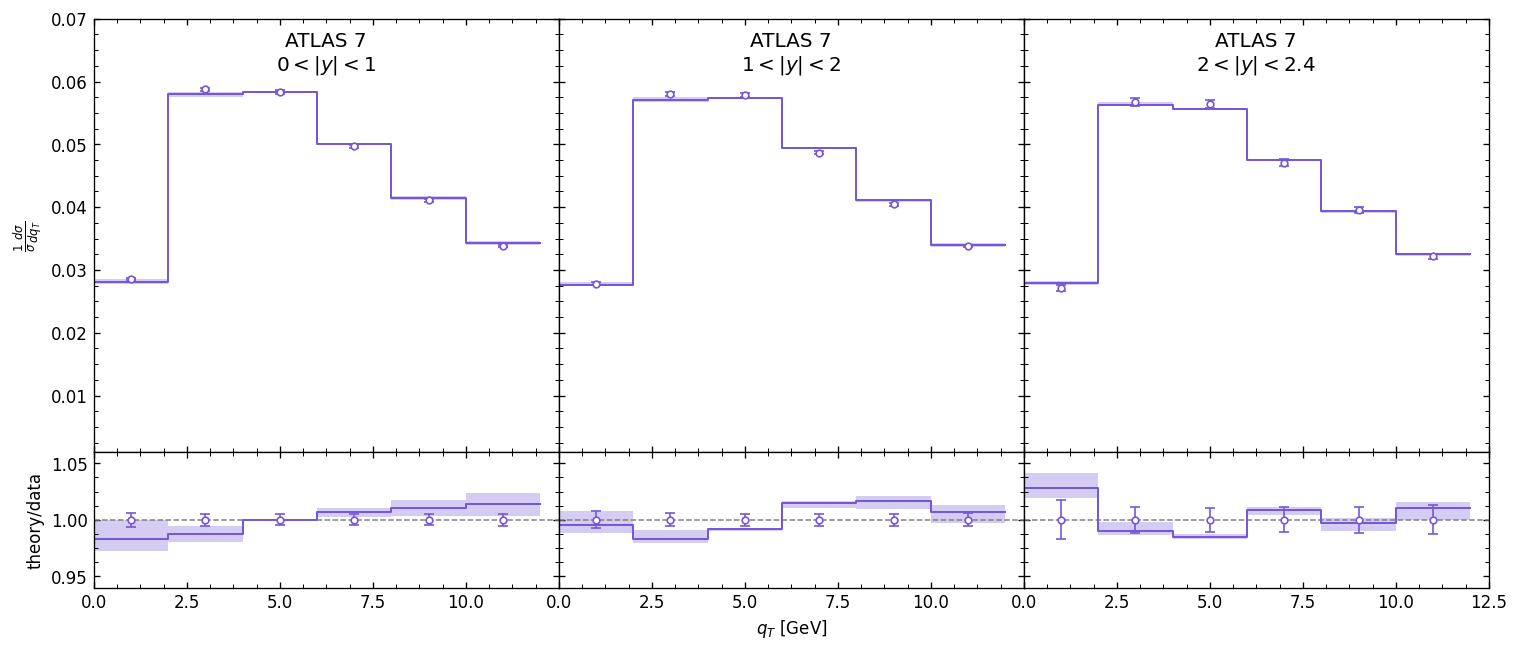

In [15]:
atlas7_files = [file for file in file_names if file.startswith("ATLAS_7/") and file in plots_list]

if not atlas7_files:
    raise ValueError("No ATLAS7 datasets are available in the current selection")

atlas7_specs = []
for file in atlas7_files:
    raw_df = data_list[file]
    y_lo = float(raw_df["y_min"].iloc[0])
    y_hi = float(raw_df["y_max"].iloc[0])
    atlas7_specs.append((y_lo, y_hi, file))

atlas7_specs = sorted(atlas7_specs, key=lambda item: (item[0], item[1]))
atlas7_colors = {(y_lo, y_hi): HIGH_ENERGY_COLOR for y_lo, y_hi, _ in atlas7_specs}


def choose_atlas7_tick_step(x_max, target_ticks=5):
    candidates = (1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


atlas7_main_max = max(
    max(
        np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float)),
        np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float)),
    )
    for _, _, fname in atlas7_specs
)
atlas7_ratio_half_span = max(
    max(
        abs(1.0 - np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float))),
        abs(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float)) - 1.0),
        np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float)),
    )
    for _, _, fname in atlas7_specs
)
atlas7_ratio_half_span = max(0.08, 1.15 * float(atlas7_ratio_half_span))

fig, axes = plt.subplots(
    2,
    len(atlas7_specs),
    figsize=(15, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
if len(atlas7_specs) == 1:
    axes = np.array([[axes[0]], [axes[1]]], dtype=object)

fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

for panel_idx, (y_lo, y_hi, fname) in enumerate(atlas7_specs):
    ax_main = axes[0, panel_idx]
    ax_ratio = axes[1, panel_idx]
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(y_lo, y_hi, fname)], atlas7_colors)
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        f"ATLAS 7\n${y_lo:g} < |y| < {y_hi:g}$",
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * atlas7_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(atlas7_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - atlas7_ratio_half_span, 1.0 + atlas7_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx == len(atlas7_specs) // 2:
        ax_ratio.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax_ratio.set_xlabel("")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

axes[0, 0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
axes[1, 0].set_ylabel("theory/data")

# Optional shared y-limits across all three columns
# Examples:

atlas7_upper_ylim = (0.001, 0.07)
atlas7_ratio_ylim = (0.94, 1.06)

if atlas7_upper_ylim is not None:
    for ax in axes[0]:
        ax.set_ylim(*atlas7_upper_ylim)

if atlas7_ratio_ylim is not None:
    for ax in axes[1]:
        ax.set_ylim(*atlas7_ratio_ylim)

plt.show()


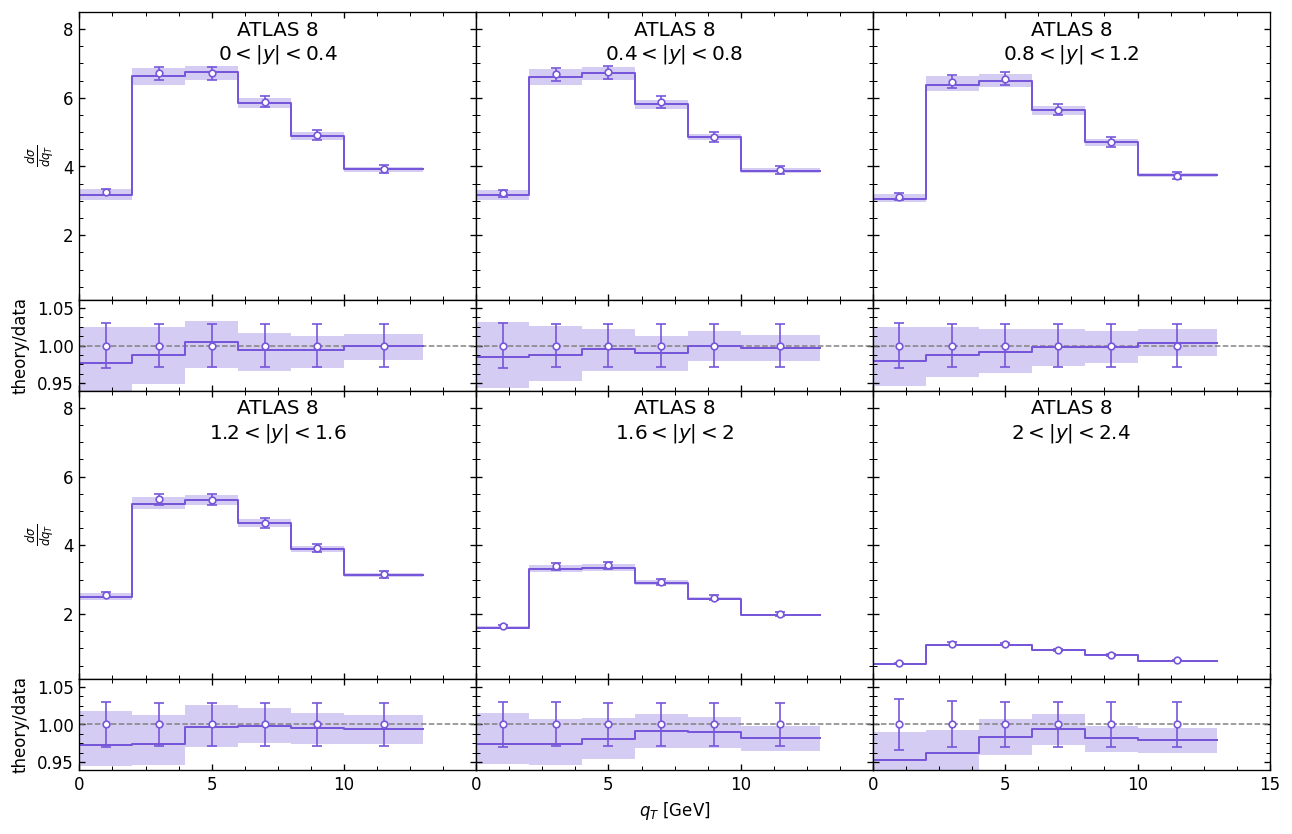

In [16]:
atlas8_files = [
    file
    for file in file_names
    if file.startswith("ATLAS_8/") and file in plots_list and "y" in Path(file).stem
]

if not atlas8_files:
    raise ValueError("No ATLAS8 rapidity-bin datasets are available in the current selection")

atlas8_specs = []
for file in atlas8_files:
    raw_df = data_list[file]
    y_lo = float(raw_df["y_min"].iloc[0])
    y_hi = float(raw_df["y_max"].iloc[0])
    atlas8_specs.append((y_lo, y_hi, file))

atlas8_specs = sorted(atlas8_specs, key=lambda item: (item[0], item[1]))
atlas8_colors = {(y_lo, y_hi): HIGH_ENERGY_COLOR for y_lo, y_hi, _ in atlas8_specs}


def choose_atlas8_tick_step(x_max, target_ticks=5):
    candidates = (1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


atlas8_main_max = max(
    max(
        np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float)),
        np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float)),
    )
    for _, _, fname in atlas8_specs
)
atlas8_ratio_half_span = max(
    max(
        abs(1.0 - np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float))),
        abs(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float)) - 1.0),
        np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float)),
    )
    for _, _, fname in atlas8_specs
)
atlas8_ratio_half_span = max(0.08, 1.15 * float(atlas8_ratio_half_span))

fig = plt.figure(figsize=(12.8, 8.2))
outer = fig.add_gridspec(2, 3, wspace=0.0, hspace=0.0)
main_axes = []
ratio_axes = []

for panel_idx, (y_lo, y_hi, fname) in enumerate(atlas8_specs):
    row_idx = panel_idx // 3
    col_idx = panel_idx % 3
    subgrid = outer[row_idx, col_idx].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
    share_main = main_axes[0] if main_axes else None
    share_ratio = ratio_axes[0] if ratio_axes else None
    ax_main = fig.add_subplot(subgrid[0], sharey=share_main)
    ax_ratio = fig.add_subplot(subgrid[1], sharex=ax_main, sharey=share_ratio)
    main_axes.append(ax_main)
    ratio_axes.append(ax_ratio)

    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas8_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(y_lo, y_hi, fname)], atlas8_colors)
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        f"ATLAS 8\n${y_lo:g} < |y| < {y_hi:g}$",
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * atlas8_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(atlas8_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - atlas8_ratio_half_span, 1.0 + atlas8_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx in (1, 4):
        ax_ratio.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax_ratio.set_xlabel("")

    if col_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)
    if row_idx == 0:
        ax_ratio.tick_params(labelbottom=False)

for idx in (0, 3):
    main_axes[idx].set_ylabel(r"$\frac{d\sigma}{dq_T}$")
    ratio_axes[idx].set_ylabel("theory/data")

# Optional shared y-limits across all ATLAS8 columns

atlas8_upper_ylim = (0.1,8.5)
atlas8_ratio_ylim = (0.94,1.06)

if atlas8_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*atlas8_upper_ylim)

if atlas8_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*atlas8_ratio_ylim)

plt.show()


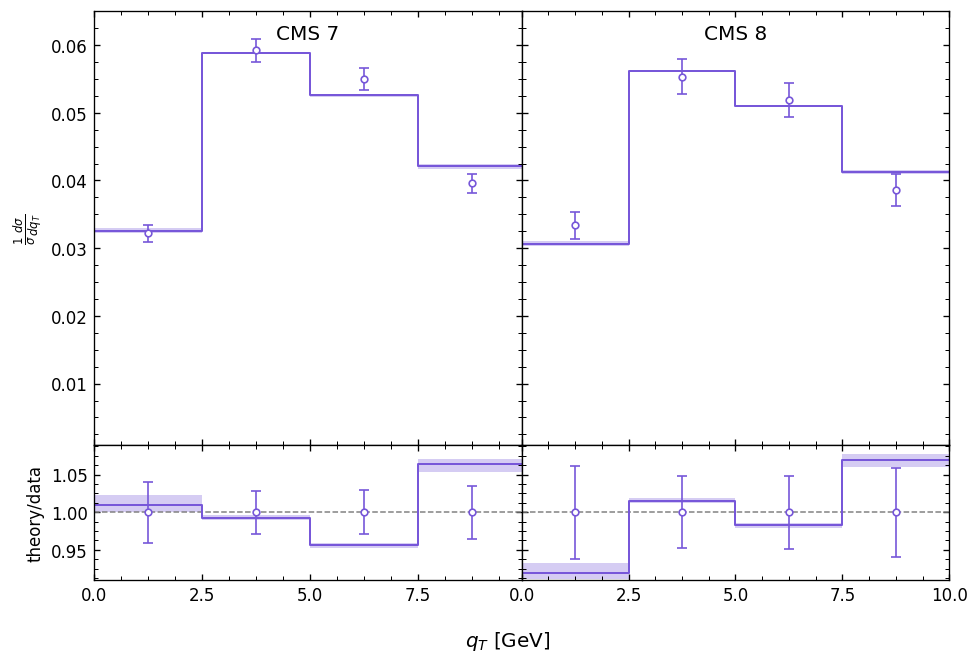

In [17]:
cms7_files = [file for file in file_names if file.startswith("CMS_7/") and file in plots_list]
cms8_files = [file for file in file_names if file.startswith("CMS_8/") and file in plots_list]

if not cms7_files:
    raise ValueError("No CMS7 datasets are available in the current selection")
if not cms8_files:
    raise ValueError("No CMS8 datasets are available in the current selection")

cms_specs = [("CMS 7", cms7_files[0]), ("CMS 8", cms8_files[0])]

cms_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in cms_specs
)
cms_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in cms_specs
)
cms_ratio_half_span = max(0.08, 1.15 * cms_ratio_half_span)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9.2, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, 0], axes[0, 1]]
ratio_axes = [axes[1, 0], axes[1, 1]]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(cms_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 2.1, fname)], {(0.0, 2.1): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * cms_main_max)
    ax_main.set_xlim(0.0, x_upper-0.1)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper-0.1)
    if panel_idx < len(cms_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - cms_ratio_half_span, 1.0 + cms_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
# cms78_upper_ylim = (0.0, 0.07)
# cms78_ratio_ylim = (0.94, 1.06)
cms78_upper_ylim = (0.001, 0.065)
cms78_ratio_ylim = (0.91, 1.09)

if cms78_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*cms78_upper_ylim)

if cms78_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*cms78_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


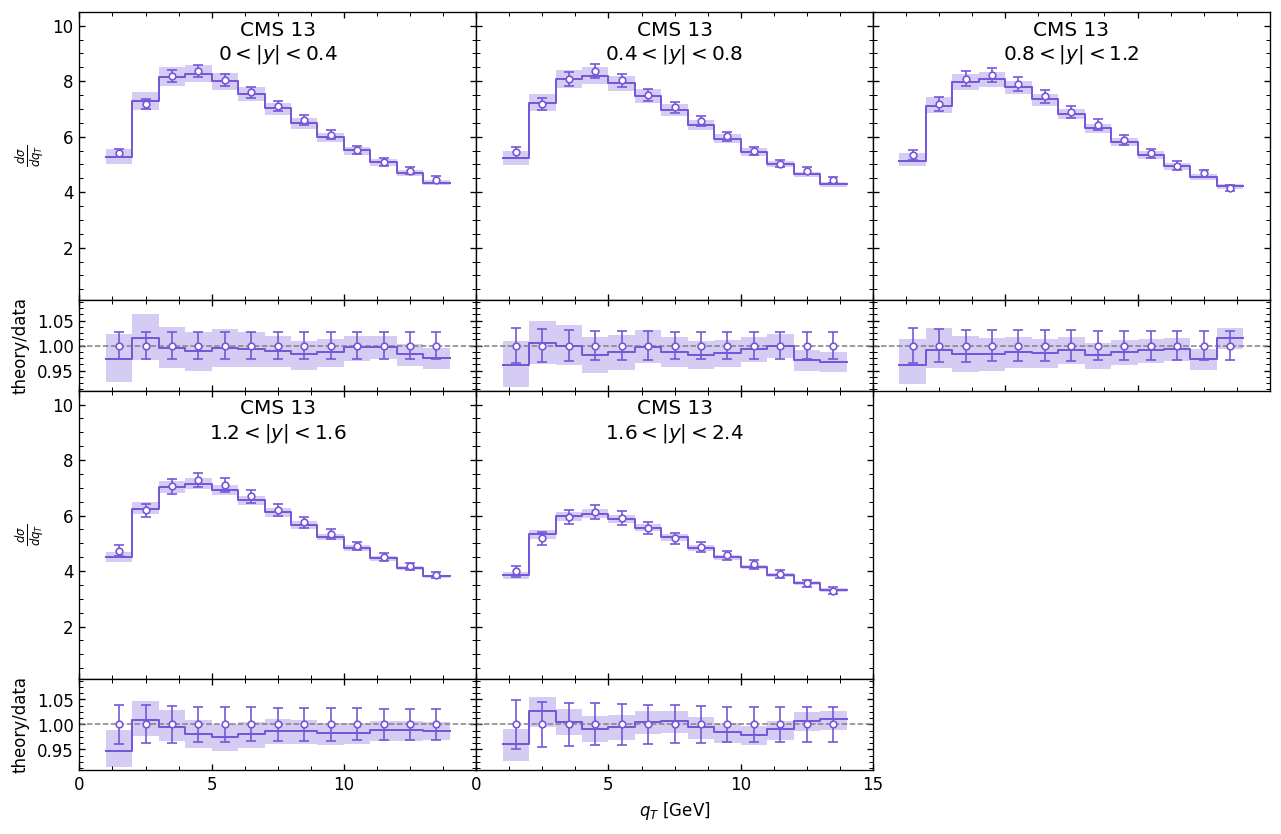

In [18]:
cms13_files = [
    file
    for file in file_names
    if file.startswith("CMS_13/") and file in plots_list and "y" in Path(file).stem
]

if not cms13_files:
    raise ValueError("No CMS13 rapidity-bin datasets are available in the current selection")

cms13_specs = []
for file in cms13_files:
    raw_df = data_list[file]
    y_lo = float(raw_df["y_min"].iloc[0])
    y_hi = float(raw_df["y_max"].iloc[0])
    cms13_specs.append((y_lo, y_hi, file))

cms13_specs = sorted(cms13_specs, key=lambda item: (item[0], item[1]))
cms13_colors = {(y_lo, y_hi): HIGH_ENERGY_COLOR for y_lo, y_hi, _ in cms13_specs}


def choose_cms13_tick_step(x_max, target_ticks=5):
    candidates = (1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


cms13_main_max = max(
    max(
        np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float)),
        np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float)),
    )
    for _, _, fname in cms13_specs
)
cms13_ratio_half_span = max(
    max(
        abs(1.0 - np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float))),
        abs(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float)) - 1.0),
        np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float)),
    )
    for _, _, fname in cms13_specs
)
cms13_ratio_half_span = max(0.08, 1.15 * float(cms13_ratio_half_span))

fig = plt.figure(figsize=(12.8, 8.2))
outer = fig.add_gridspec(2, 3, wspace=0.0, hspace=0.0)
main_axes = []
ratio_axes = []

for panel_idx, (y_lo, y_hi, fname) in enumerate(cms13_specs):
    row_idx = panel_idx // 3
    col_idx = panel_idx % 3
    subgrid = outer[row_idx, col_idx].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
    share_main = main_axes[0] if main_axes else None
    share_ratio = ratio_axes[0] if ratio_axes else None
    ax_main = fig.add_subplot(subgrid[0], sharey=share_main)
    ax_ratio = fig.add_subplot(subgrid[1], sharex=ax_main, sharey=share_ratio)
    main_axes.append(ax_main)
    ratio_axes.append(ax_ratio)

    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_cms13_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(y_lo, y_hi, fname)], cms13_colors)
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        f"CMS 13\n${y_lo:g} < |y| < {y_hi:g}$",
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * cms13_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(cms13_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - cms13_ratio_half_span, 1.0 + cms13_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx in (1, 4):
        ax_ratio.set_xlabel(r"$q_T$ [GeV]")
    else:
        ax_ratio.set_xlabel("")

    if col_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)
    if row_idx == 0:
        ax_ratio.tick_params(labelbottom=False)

# hide the unused 6th slot
empty_subgrid = outer[1, 2].subgridspec(2, 1, height_ratios=[3.2, 1.0], hspace=0.0)
fig.add_subplot(empty_subgrid[0]).axis("off")
fig.add_subplot(empty_subgrid[1]).axis("off")

for idx in (0, 3):
    main_axes[idx].set_ylabel(r"$\frac{d\sigma}{dq_T}$")
    ratio_axes[idx].set_ylabel("theory/data")

# Optional shared y-limits across all CMS13 columns
# cms13_upper_ylim = (0.1,10)
# cms13_ratio_ylim = (0.88, 1.12)
cms13_upper_ylim = (0.1,10.5)
cms13_ratio_ylim = (0.91, 1.09)

if cms13_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*cms13_upper_ylim)

if cms13_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*cms13_ratio_ylim)

plt.show()


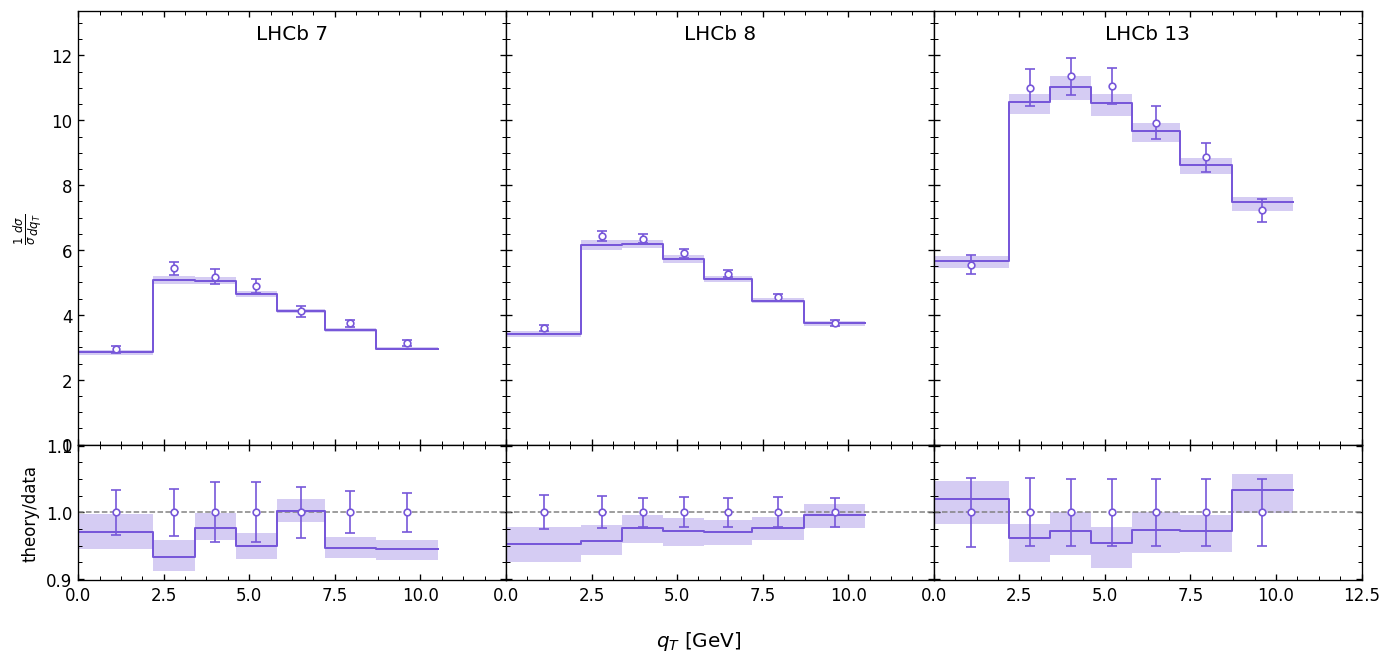

In [19]:
lhcb7_files = [file for file in file_names if file.startswith("LHCb_7/") and file in plots_list]
lhcb8_files = [file for file in file_names if file.startswith("LHCb_8/") and file in plots_list]
lhcb13_files = [file for file in file_names if file.startswith("LHCb_13/") and file in plots_list]

if not lhcb7_files:
    raise ValueError("No LHCb 7 datasets are available in the current selection")
if not lhcb8_files:
    raise ValueError("No LHCb 8 datasets are available in the current selection")
if not lhcb13_files:
    raise ValueError("No LHCb 13 datasets are available in the current selection")

lhcb_specs = [("LHCb 7", lhcb7_files[0]), ("LHCb 8", lhcb8_files[0]), ("LHCb 13", lhcb13_files[0])]

lhcb_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in lhcb_specs
)
lhcb_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in lhcb_specs
)
lhcb_ratio_half_span = max(0.08, 1.15 * lhcb_ratio_half_span)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13.8, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, 0], axes[0, 1], axes[0, 2]]
ratio_axes = [axes[1, 0], axes[1, 1], axes[1, 2]]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(lhcb_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 1.0, fname)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * lhcb_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(lhcb_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - lhcb_ratio_half_span, 1.0 + lhcb_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
lhcb_upper_ylim = None
lhcb_ratio_ylim = None

if lhcb_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*lhcb_upper_ylim)

if lhcb_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*lhcb_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


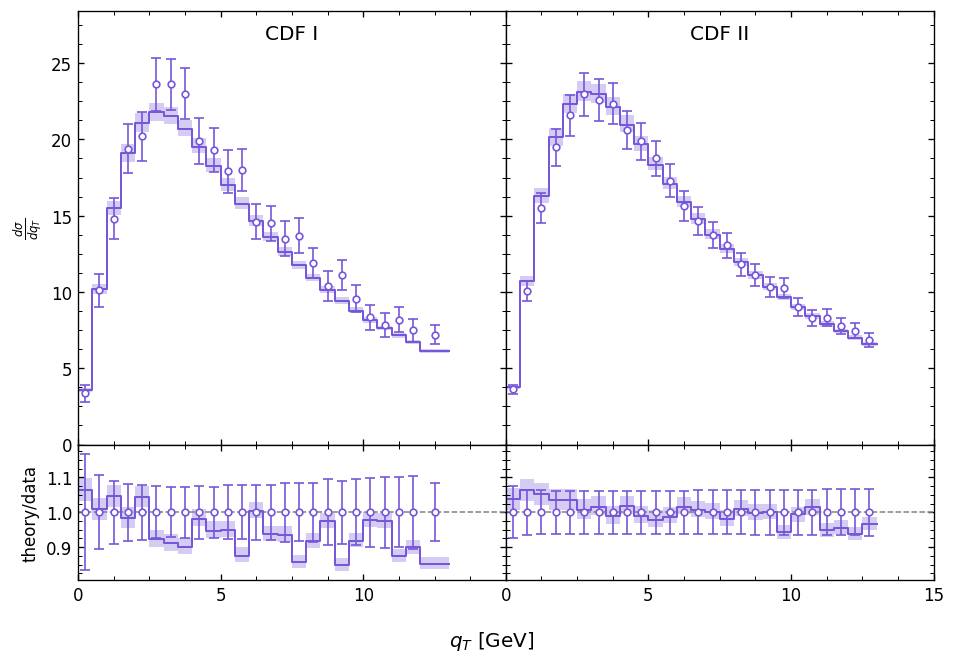

In [20]:
cdf1_files = [file for file in file_names if file.startswith("CDF_I/") and file in plots_list]
cdf2_files = [file for file in file_names if file.startswith("CDF_II/") and file in plots_list]

if not cdf1_files:
    raise ValueError("No CDF I datasets are available in the current selection")
if not cdf2_files:
    raise ValueError("No CDF II datasets are available in the current selection")

cdf_specs = [("CDF I", cdf1_files[0]), ("CDF II", cdf2_files[0])]

cdf_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in cdf_specs
)
cdf_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in cdf_specs
)
cdf_ratio_half_span = max(0.08, 1.15 * cdf_ratio_half_span)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(9.2, 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, 0], axes[0, 1]]
ratio_axes = [axes[1, 0], axes[1, 1]]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(cdf_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 1.0, fname)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * cdf_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(cdf_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - cdf_ratio_half_span, 1.0 + cdf_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
cdf_upper_ylim = (0.1, 39)
cdf_ratio_ylim = (0.81, 1.19)
cdf_upper_ylim = None
cdf_ratio_ylim = None

if cdf_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*cdf_upper_ylim)

if cdf_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*cdf_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


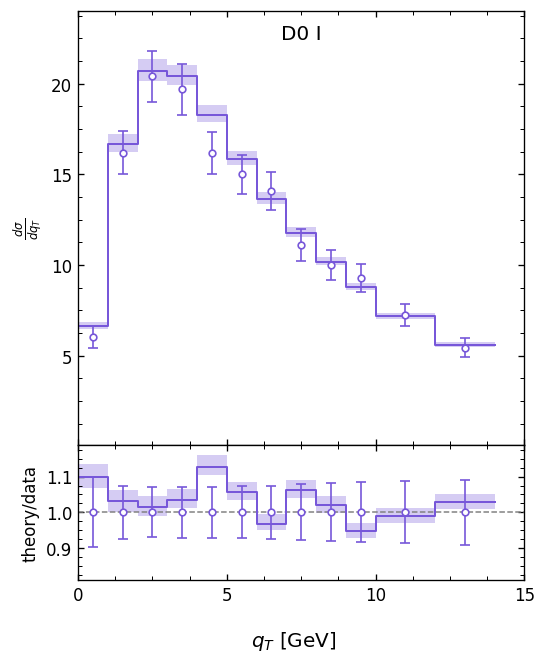

In [21]:
d0i_files = [file for file in file_names if file.startswith("D0_I/") and file in plots_list]

if not d0i_files:
    raise ValueError("No D0 I datasets are available in the current selection")

d0i_file = d0i_files[0]
d0i_panel_x_max = float(data_list[d0i_file]["qT_max"].max())
d0i_main_max = max(
    float(np.nanmax(plots_list[d0i_file]["pred_hi"].to_numpy(dtype=float))),
    float(np.nanmax((plots_list[d0i_file]["data"] + plots_list[d0i_file]["data_err"]).to_numpy(dtype=float))),
)
d0i_ratio_half_span = max(
    abs(1.0 - float(np.nanmin(plots_list[d0i_file]["ratio_lo"].to_numpy(dtype=float)))),
    abs(float(np.nanmax(plots_list[d0i_file]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
    float(np.nanmax(plots_list[d0i_file]["ratio_err"].to_numpy(dtype=float))),
)
d0i_ratio_half_span = max(0.08, 1.15 * d0i_ratio_half_span)
d0i_x_tick_step = choose_atlas7_tick_step(d0i_panel_x_max)
d0i_x_upper = d0i_x_tick_step * np.ceil(d0i_panel_x_max / d0i_x_tick_step)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(4.8, 6.0),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
ax_main, ax_ratio = axes
fig.subplots_adjust(hspace=0.0, top=0.95, bottom=0.16)

plot_q_bin_overlay(ax_main, [(0.0, 1.0, d0i_file)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
plot_ratio_panel(ax_ratio, d0i_file, color=HIGH_ENERGY_COLOR)

ax_main.text(
    0.5,
    0.97,
    "D0 I",
    transform=ax_main.transAxes,
    ha="center",
    va="top",
    fontsize=12,
)
ax_main.set_ylim(0.0, 1.12 * d0i_main_max)
ax_main.set_xlim(0.0, d0i_x_upper)
ax_main.tick_params(which="both", direction="in", top=True, right=True)
ax_main.grid(False)
ax_main.tick_params(labelbottom=False)
ax_main.xaxis.set_minor_locator(MultipleLocator(float(d0i_x_tick_step) / 4.0))
ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

ax_ratio.set_xlim(0.0, d0i_x_upper)
ax_ratio.set_xticks(np.arange(0.0, d0i_x_upper + 0.5 * d0i_x_tick_step, d0i_x_tick_step))
ax_ratio.set_ylim(1.0 - d0i_ratio_half_span, 1.0 + d0i_ratio_half_span)
ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
ax_ratio.grid(False)
apply_dense_minor_ticks(ax_ratio, d0i_x_tick_step, y_scale="linear")

ax_main.set_ylabel(r"$\frac{d\sigma}{dq_T}$")
ax_ratio.set_ylabel("theory/data")

# Optional shared y-limits
d0i_upper_ylim = (0.1, 24)
d0i_ratio_ylim = (0.81, 1.19)

if d0i_upper_ylim is not None:
    ax_main.set_ylim(*d0i_upper_ylim)

if d0i_ratio_ylim is not None:
    ax_ratio.set_ylim(*d0i_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


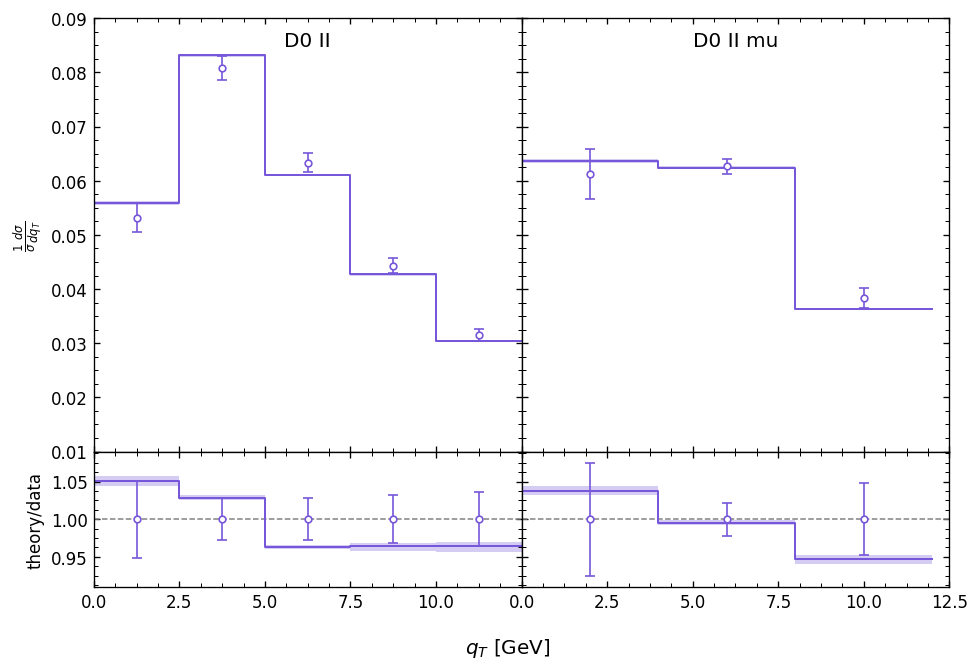

In [22]:
d0ii_specs = []
for title, prefix in [("D0 II", "D0_II/"), ("D0 II mu", "D0_II_mu/")]:
    files = [file for file in file_names if file.startswith(prefix) and file in plots_list]
    if not files:
        continue
    d0ii_specs.append((title, files[0]))

if not d0ii_specs:
    raise ValueError("No D0 II datasets are available in the current selection")

d0ii_ratio_half_span = max(
    max(
        abs(1.0 - float(np.nanmin(plots_list[fname]["ratio_lo"].to_numpy(dtype=float)))),
        abs(float(np.nanmax(plots_list[fname]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
        float(np.nanmax(plots_list[fname]["ratio_err"].to_numpy(dtype=float))),
    )
    for _, fname in d0ii_specs
)
d0ii_ratio_half_span = max(0.08, 1.15 * d0ii_ratio_half_span)
d0ii_main_max = max(
    max(
        float(np.nanmax(plots_list[fname]["pred_hi"].to_numpy(dtype=float))),
        float(np.nanmax((plots_list[fname]["data"] + plots_list[fname]["data_err"]).to_numpy(dtype=float))),
    )
    for _, fname in d0ii_specs
)

fig, axes = plt.subplots(
    2,
    len(d0ii_specs),
    figsize=(4.6 * len(d0ii_specs), 6.0),
    sharex="col",
    gridspec_kw={"height_ratios": [3.2, 1.0]},
)
if len(d0ii_specs) == 1:
    axes = np.array([[axes[0]], [axes[1]]], dtype=object)
fig.subplots_adjust(wspace=0.0, hspace=0.0, top=0.95, bottom=0.16)

main_axes = [axes[0, i] for i in range(len(d0ii_specs))]
ratio_axes = [axes[1, i] for i in range(len(d0ii_specs))]

for panel_idx, ((title, fname), ax_main, ax_ratio) in enumerate(zip(d0ii_specs, main_axes, ratio_axes)):
    panel_x_max = float(data_list[fname]["qT_max"].max())
    x_tick_step = choose_atlas7_tick_step(panel_x_max)
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)

    plot_q_bin_overlay(ax_main, [(0.0, 1.0, fname)], {(0.0, 1.0): HIGH_ENERGY_COLOR})
    plot_ratio_panel(ax_ratio, fname, color=HIGH_ENERGY_COLOR)

    ax_main.text(
        0.5,
        0.97,
        title,
        transform=ax_main.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax_main.set_ylim(0.0, 1.12 * d0ii_main_max)
    ax_main.set_xlim(0.0, x_upper)
    ax_main.tick_params(which="both", direction="in", top=True, right=True)
    ax_main.grid(False)
    ax_main.tick_params(labelbottom=False)
    ax_main.xaxis.set_minor_locator(MultipleLocator(float(x_tick_step) / 4.0))
    ax_main.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax_main.tick_params(which="minor", direction="in", top=True, right=True, length=2.5)

    ax_ratio.set_xlim(0.0, x_upper)
    if panel_idx < len(d0ii_specs) - 1:
        x_ticks = np.arange(0.0, x_upper, x_tick_step)
    else:
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax_ratio.set_xticks(x_ticks)
    ax_ratio.set_ylim(1.0 - d0ii_ratio_half_span, 1.0 + d0ii_ratio_half_span)
    ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
    ax_ratio.grid(False)
    apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")

    if panel_idx > 0:
        ax_main.tick_params(labelleft=False)
        ax_ratio.tick_params(labelleft=False)

main_axes[0].set_ylabel(r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$")
ratio_axes[0].set_ylabel("theory/data")

# Optional shared y-limits
d0ii_upper_ylim = (0.01, 0.09)
d0ii_ratio_ylim = (0.91, 1.09)

if d0ii_upper_ylim is not None:
    for ax in main_axes:
        ax.set_ylim(*d0ii_upper_ylim)

if d0ii_ratio_ylim is not None:
    for ax in ratio_axes:
        ax.set_ylim(*d0ii_ratio_ylim)

fig.supxlabel(r"$q_T$ [GeV]", y=0.06)

plt.show()


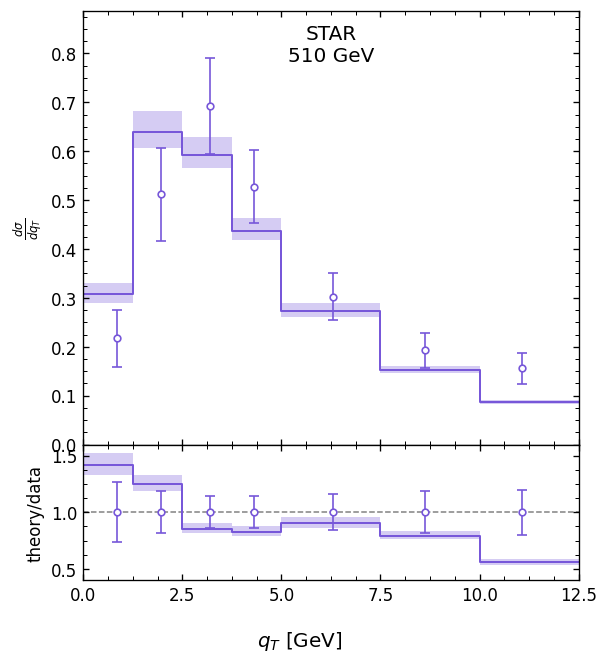

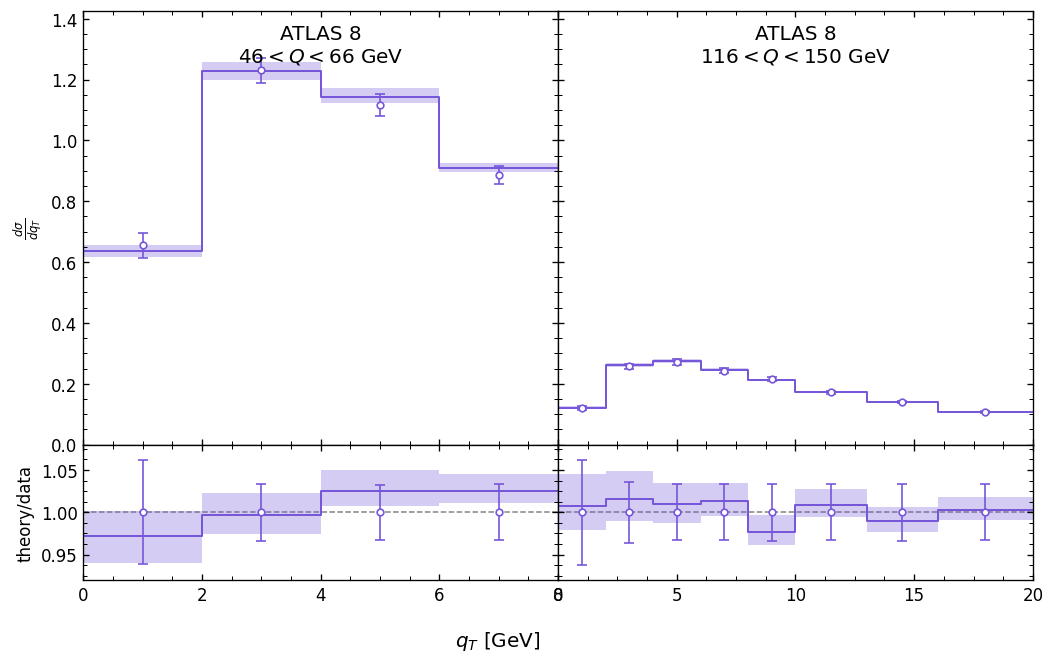

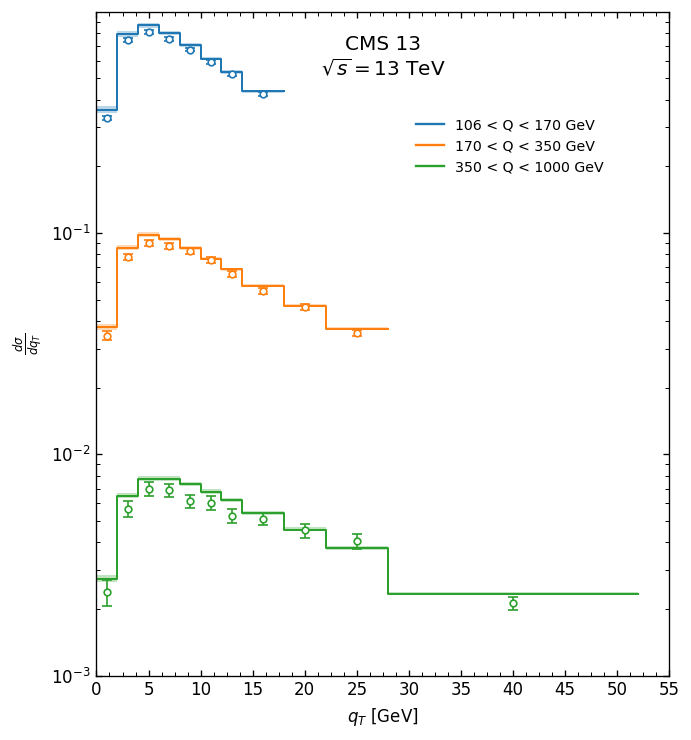

In [23]:
def overview_step_xy(x_min, x_max, values):
    edges = np.concatenate(([float(x_min[0])], np.asarray(x_max, dtype=float)))
    x_curve = np.repeat(edges, 2)[1:-1]
    y_curve = np.repeat(np.asarray(values, dtype=float), 2)
    return x_curve, y_curve


def overview_tick_step(x_max, target_ticks=5):
    candidates = (0.5, 1.0, 2.0, 2.5, 5.0)
    best_step = candidates[0]
    best_score = None
    for step in candidates:
        n_ticks = int(np.ceil(x_max / step)) + 1
        score = abs(n_ticks - target_ticks)
        if best_score is None or score < best_score:
            best_step = step
            best_score = score
    return best_step


def overview_is_normalized(file):
    raw_df = data_list[file]
    if "observable" not in raw_df.columns:
        return False
    observable = str(raw_df["observable"].iloc[0])
    return observable.startswith("1/")


def overview_ylabel(file):
    if overview_is_normalized(file):
        return r"$\frac{1}{\sigma}\frac{d\sigma}{dq_T}$"
    return r"$\frac{d\sigma}{dq_T}$"


def overview_panel_title(file):
    raw_df = data_list[file]
    experiment, stem_with_ext = file.split("/", 1)
    if file.startswith("STAR/"):
        return "STAR\n510 GeV"
    if file.startswith("ATLAS_8/"):
        experiment_label = "ATLAS 8"
    elif file.startswith("CMS_13/"):
        experiment_label = "CMS 13"
    else:
        experiment_label = experiment.replace('_', ' ')
    if {"Q_min", "Q_max"}.issubset(raw_df.columns):
        q_lo = float(raw_df["Q_min"].iloc[0])
        q_hi = float(raw_df["Q_max"].iloc[0])
        if q_hi > q_lo:
            return f"{experiment_label}\n${q_lo:g} < Q < {q_hi:g}$ GeV"
    return f"{experiment_label}\n{Path(stem_with_ext).stem}"


def overview_ratio_half_span(files):
    raw_span = max(
        max(
            abs(1.0 - float(np.nanmin(plots_list[file]["ratio_lo"].to_numpy(dtype=float)))),
            abs(float(np.nanmax(plots_list[file]["ratio_hi"].to_numpy(dtype=float))) - 1.0),
            float(np.nanmax(plots_list[file]["ratio_err"].to_numpy(dtype=float))),
        )
        for file in files
    )
    return max(0.08, 1.15 * raw_span)


def overview_group_ymax(files):
    ymax = max(
        max(
            float(np.nanmax(plots_list[file]["pred_hi"].to_numpy(dtype=float))),
            float(np.nanmax((plots_list[file]["data"] + plots_list[file]["data_err"]).to_numpy(dtype=float))),
        )
        for file in files
    )
    return 1.12 * ymax


def overview_group_log_ymin(files):
    positive_values = []
    for file in files:
        d = plots_list[file]
        data_vals = d["data"].to_numpy(dtype=float)
        data_err = d["data_err"].to_numpy(dtype=float)
        pred_lo = d["pred_lo"].to_numpy(dtype=float)
        central = d["central"].to_numpy(dtype=float)
        pred_hi = d["pred_hi"].to_numpy(dtype=float)
        lower_data = data_vals - data_err
        candidates = np.concatenate([data_vals, lower_data, pred_lo, central, pred_hi])
        positive = candidates[np.isfinite(candidates) & (candidates > 0.0)]
        if positive.size:
            positive_values.append(float(np.nanmin(positive)))
    if not positive_values:
        return 1e-4
    raw_min = min(positive_values)
    return float(10.0 ** np.floor(np.log10(raw_min)))


def overview_q_bin(file):
    raw_df = data_list[file]
    if not {"Q_min", "Q_max"}.issubset(raw_df.columns):
        raise ValueError(f"Missing Q-bin information for {file}")
    return float(raw_df["Q_min"].iloc[0]), float(raw_df["Q_max"].iloc[0])


def render_overview_group(group_title, grouped_files, color):
    if not grouped_files:
        return

    missing = [file for file in grouped_files if file not in plots_list]
    if missing:
        raise ValueError(f"Missing datasets in plots_list for {group_title}: {missing}")

    ncols = len(grouped_files)
    fig_width = 4.8 if ncols == 1 else 4.6 * ncols
    fig, axes = plt.subplots(
        2,
        ncols,
        figsize=(fig_width, 6.0),
        sharex="col",
        sharey="row",
        gridspec_kw={"height_ratios": [3.2, 1.0]},
    )
    if ncols == 1:
        axes = np.array([[axes[0]], [axes[1]]], dtype=object)

    fig.subplots_adjust(left=0.125, right=0.985, top=0.95, bottom=0.16, wspace=0.0, hspace=0.0)

    group_ratio_half_span = overview_ratio_half_span(grouped_files)
    group_ymax = overview_group_ymax(grouped_files)

    main_axes = [axes[0, idx] for idx in range(ncols)]
    ratio_axes = [axes[1, idx] for idx in range(ncols)]

    for panel_idx, (file, ax_main, ax_ratio) in enumerate(zip(grouped_files, main_axes, ratio_axes)):
        raw_df = data_list[file]
        d = plots_list[file]
        qT = d["qT"].to_numpy(dtype=float)
        qT_min = raw_df["qT_min"].to_numpy(dtype=float)
        qT_max = raw_df["qT_max"].to_numpy(dtype=float)
        data_vals = d["data"].to_numpy(dtype=float)
        data_err = d["data_err"].to_numpy(dtype=float)
        central = d["central"].to_numpy(dtype=float)
        pred_lo = d["pred_lo"].to_numpy(dtype=float)
        pred_hi = d["pred_hi"].to_numpy(dtype=float)
        central_ratio = d["central_ratio"].to_numpy(dtype=float)
        ratio_lo = d["ratio_lo"].to_numpy(dtype=float)
        ratio_hi = d["ratio_hi"].to_numpy(dtype=float)
        ratio_err = d["ratio_err"].to_numpy(dtype=float)

        x_curve, central_curve = overview_step_xy(qT_min, qT_max, central)
        _, lo_curve = overview_step_xy(qT_min, qT_max, pred_lo)
        _, hi_curve = overview_step_xy(qT_min, qT_max, pred_hi)
        _, central_ratio_curve = overview_step_xy(qT_min, qT_max, central_ratio)
        _, ratio_lo_curve = overview_step_xy(qT_min, qT_max, ratio_lo)
        _, ratio_hi_curve = overview_step_xy(qT_min, qT_max, ratio_hi)

        ax_main.fill_between(x_curve, lo_curve, hi_curve, color=color, alpha=0.3, linewidth=0.0, zorder=1)
        ax_main.plot(x_curve, central_curve, color=color, linewidth=1.2, drawstyle="steps-mid", zorder=2)
        ax_main.errorbar(
            qT,
            data_vals,
            yerr=data_err,
            fmt="o",
            ms=4.0,
            elinewidth=1.0,
            capsize=2.8,
            color=color,
            mec=color,
            mfc="white",
            zorder=3,
        )

        ax_ratio.axhline(1.0, color="0.5", linewidth=0.9, linestyle="--", zorder=1)
        ax_ratio.fill_between(x_curve, ratio_lo_curve, ratio_hi_curve, color=color, alpha=0.3, linewidth=0.0, zorder=1)
        ax_ratio.plot(x_curve, central_ratio_curve, color=color, linewidth=1.2, drawstyle="steps-mid", zorder=2)
        ax_ratio.errorbar(
            qT,
            np.ones_like(qT),
            yerr=ratio_err,
            fmt="o",
            ms=4.0,
            elinewidth=1.0,
            capsize=2.8,
            color=color,
            mec=color,
            mfc="white",
            zorder=3,
        )

        panel_x_max = float(qT_max.max())
        x_tick_step = overview_tick_step(panel_x_max)
        x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)
        x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)

        ax_main.set_xlim(0.0, x_upper)
        ax_ratio.set_xlim(0.0, x_upper)
        ax_main.set_ylim(0.0, group_ymax)
        ax_ratio.set_ylim(1.0 - group_ratio_half_span, 1.0 + group_ratio_half_span)
        ax_ratio.set_xticks(x_ticks)

        ax_main.tick_params(which="both", direction="in", top=True, right=True)
        ax_main.grid(False)
        apply_dense_minor_ticks(ax_main, x_tick_step, y_scale="linear")
        ax_ratio.tick_params(which="both", direction="in", top=True, right=True)
        ax_ratio.grid(False)
        apply_dense_minor_ticks(ax_ratio, x_tick_step, y_scale="linear")
        ax_main.tick_params(labelbottom=False)
        ax_main.text(
            0.5,
            0.97,
            overview_panel_title(file),
            transform=ax_main.transAxes,
            ha="center",
            va="top",
            fontsize=12,
        )

        if panel_idx > 0:
            ax_main.tick_params(labelleft=False)
            ax_ratio.tick_params(labelleft=False)
        else:
            ax_main.set_ylabel(overview_ylabel(file))
            ax_ratio.set_ylabel("theory/data")

    fig.supxlabel(r"$q_T$ [GeV]", y=0.06)
    plt.show()


def render_cms13_merged_overview(group_title, grouped_files):
    if not grouped_files:
        return

    missing = [file for file in grouped_files if file not in plots_list]
    if missing:
        raise ValueError(f"Missing datasets in plots_list for {group_title}: {missing}")

    cms_specs = []
    for file in grouped_files:
        q_lo, q_hi = overview_q_bin(file)
        cms_specs.append((q_lo, q_hi, file))
    cms_specs = sorted(cms_specs, key=lambda item: (item[0], item[1]))
    cms_q_bins = [(q_lo, q_hi) for q_lo, q_hi, _ in cms_specs]
    cms_colors = make_q_bin_colors(cms_q_bins)

    fig, ax = plt.subplots(1, 1, figsize=(7.4, 7.0))
    fig.subplots_adjust(right=0.77, top=0.95, bottom=0.16)

    panel_x_max = max(float(data_list[fname]["qT_max"].max()) for _, _, fname in cms_specs)
    plot_q_bin_overlay(ax, cms_specs, cms_colors)

    ax.text(
        0.5,
        0.965,
        "CMS 13\n$\\sqrt{s} = 13\ \mathrm{TeV}$",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
    )
    ax.set_xlabel(r"$q_T$ [GeV]")
    ax.set_ylabel(overview_ylabel(grouped_files[0]))
    ax.set_yscale("log")
    x_tick_step = 5.0
    x_upper = x_tick_step * np.ceil(panel_x_max / x_tick_step)
    x_ticks = np.arange(0.0, x_upper + 0.5 * x_tick_step, x_tick_step)
    ax.set_xlim(0.0, x_upper)
    ax.set_xticks(x_ticks)
    apply_dense_minor_ticks(ax, x_tick_step, y_scale="log")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(False)
    ax.set_ylim(overview_group_log_ymin(grouped_files), overview_group_ymax(grouped_files))

    fig.legend(
        handles=build_q_bin_legend_handles(cms_q_bins, cms_colors),
        loc="center left",
        bbox_to_anchor=(0.47, 0.79),
        frameon=False,
        fontsize=8.5,
    )

    plt.show()


OVERVIEW_GROUPS = [
    (
        "STAR",
        ["STAR/STAR510.csv"],
        HIGH_ENERGY_COLOR,
    ),
    (
        "ATLAS high-Q",
        [
            "ATLAS_8/ATLAS8-46Q66.csv",
            "ATLAS_8/ATLAS8-116Q150.csv",
        ],
        HIGH_ENERGY_COLOR,
    ),
    (
        "CMS 13 high-Q",
        [
            "CMS_13/CMS13-106Q170.csv",
            "CMS_13/CMS13-170Q350.csv",
            "CMS_13/CMS13-350Q1000.csv",
        ],
        HIGH_ENERGY_COLOR,
    ),
]


for group_title, grouped_files, group_color in OVERVIEW_GROUPS:
    if group_title == "CMS 13 high-Q":
        render_cms13_merged_overview(group_title, grouped_files)
    else:
        render_overview_group(group_title, grouped_files, group_color)
